In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import h5py
import os
from pathlib import Path
from scipy.ndimage import uniform_filter1d
import pandas as pd
import warnings
import matplotlib as mpl
import json

# Suprimir avisos
warnings.filterwarnings('ignore')

# --- CONFIGURAÇÕES DE ESTILO (TESE) ---
plt.style.use('seaborn-v0_8-whitegrid')

# Cores padrão brasileiro e Tese
CORES = {
    'A': '#00FFFF',  # Ciano
    'B': '#FF3232',  # Vermelho
    'C': '#00FF00',  # Verde
    'Ref': '#969696'
}

CORES_TESE = {
    'A': '#0066CC',
    'B': '#CC0000',
    'C': '#009900',
    'T2F': '#FF6600',
    'MRT': '#6600CC',
    'Com_Terra': '#008B8B',
    'Sem_Terra': '#B8860B',
}

# Parâmetros de Plotagem para Publicação (DPI 600)
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11
mpl.rcParams['legend.framealpha'] = 0.95
mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['grid.alpha'] = 0.3
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['axes.grid'] = True

print("✅ Bibliotecas carregadas e configurações de estilo aplicadas!")

✅ Bibliotecas carregadas e configurações de estilo aplicadas!


In [2]:
# 🔧 CONFIGURE AQUI SEUS CAMINHOS
PASTA_DADOS = (
    "C:/Users/Leonardo Felipe/OneDrive/Coisas_Leonardo/gits/CurtosT2F/"
    "T2F_MATLAB/NovoArtigoPowerDelivery34bus/NovoModeloQualificacao/"
    "Teste_Novo_Sem_Terra_14/Processados_HDF5/"
)

PASTA_SAIDA = "./resultados_analise_14"
PASTA_TESE = Path(PASTA_SAIDA) / "Capitulo_4_Figuras_Tese"

# Cria pastas de saída
Path(PASTA_SAIDA).mkdir(parents=True, exist_ok=True)
PASTA_TESE.mkdir(parents=True, exist_ok=True)

# Configurações do Sistema
BARRAS_DISPONIVEIS = ["800", "818", "820", "822", "T2F1", "T2F"]
FREQ = 60  # Hz

print("✅ Configuração de pastas:")
print(f"   📂 Dados: {PASTA_DADOS}")
print(f"   💾 Saída Geral: {PASTA_SAIDA}")
print(f"   🎓 Saída Tese: {PASTA_TESE}")

✅ Configuração de pastas:
   📂 Dados: C:/Users/Leonardo Felipe/OneDrive/Coisas_Leonardo/gits/CurtosT2F/T2F_MATLAB/NovoArtigoPowerDelivery34bus/NovoModeloQualificacao/Teste_Novo_Sem_Terra_13/Processados_HDF5/
   💾 Saída Geral: ./resultados_analise_13
   🎓 Saída Tese: resultados_analise_13\Capitulo_4_Figuras_Tese


In [3]:
def carregar_mat(caminho):
    """Carrega arquivo .mat (v7.3 HDF5 ou formato antigo)."""
    try:
        with h5py.File(caminho, 'r') as f:
            dados = {}
            for key in f.keys():
                if not key.startswith('__'):
                    try:
                        item = f[key]
                        if isinstance(item, h5py.Dataset):
                            dados[key] = item[()]
                            if isinstance(dados[key], np.ndarray) and dados[key].ndim == 2:
                                if dados[key].shape[0] == 3 and dados[key].shape[1] > 3:
                                    dados[key] = dados[key].T
                    except Exception as e:
                        print(f"  ⚠️ Aviso ao ler '{key}': {e}")
            return dados
    except Exception:
        try:
            return sio.loadmat(caminho, squeeze_me=False)
        except Exception as e:
            print(f"❌ Erro ao carregar {caminho}: {e}")
            return None

def identificar_barras_no_arquivo(dados):
    """Identifica barras presentes no arquivo."""
    barras_encontradas = []
    for key in dados.keys():
        if '_raw' in key and not key.startswith('__'):
            partes = key.split('_')
            if len(partes) >= 2:
                barra = partes[1]
                if barra not in barras_encontradas:
                    barras_encontradas.append(barra)
    return sorted(barras_encontradas)

def _garantir_3_fases(arr):
    """Garante array com shape (N, 3)."""
    arr = np.array(arr, dtype=np.float64)
    if arr.ndim == 1:
        return np.column_stack([arr, arr, arr])
    if arr.shape[0] == 3 and arr.shape[1] > 3:
        return arr.T
    if arr.shape[1] == 3:
        return arr
    if arr.ndim >= 2 and arr.shape[1] >= 3:
        return arr[:, :3]
    if arr.ndim >= 2:
        col = arr[:, 0]
        return np.column_stack([col, col, col])
    return arr

def extrair_dados_barra(dados, barra):
    """Extrai t, V, I de uma barra específica."""
    chaves_v = [f'V_{barra}_raw', f'V_{barra}', f'v_{barra}_raw']
    chaves_i = [f'I_{barra}_raw', f'I_{barra}', f'i_{barra}_raw']
    chaves_t = ['t', 'time', 'tempo']

    t = None
    for key in chaves_t:
        if key in dados:
            t = np.array(dados[key]).flatten()
            break

    V = None
    for key in chaves_v:
        if key in dados:
            V = np.array(dados[key])
            break

    I = None
    for key in chaves_i:
        if key in dados:
            I = np.array(dados[key])
            break

    if t is None or V is None or I is None:
        return None, None, None

    V = _garantir_3_fases(V)
    I = _garantir_3_fases(I)

    L = min(len(t), len(V), len(I))
    t = t[:L]
    V = V[:L, :]
    I = I[:L, :]

    return t, V, I

print("✅ Funções de carregamento definidas!")

✅ Funções de carregamento definidas!


In [4]:
def carregar_mat(caminho):
    """Carrega arquivo .mat (v7.3 HDF5 ou formato antigo)."""
    try:
        with h5py.File(caminho, 'r') as f:
            dados = {}
            for key in f.keys():
                if not key.startswith('__'):
                    try:
                        item = f[key]
                        if isinstance(item, h5py.Dataset):
                            dados[key] = item[()]
                            if isinstance(dados[key], np.ndarray) and dados[key].ndim == 2:
                                if dados[key].shape[0] == 3 and dados[key].shape[1] > 3:
                                    dados[key] = dados[key].T
                    except Exception as e:
                        print(f"  ⚠️ Aviso ao ler '{key}': {e}")
            return dados
    except Exception:
        try:
            return sio.loadmat(caminho, squeeze_me=False)
        except Exception as e:
            print(f"❌ Erro ao carregar {caminho}: {e}")
            return None

def identificar_barras_no_arquivo(dados):
    """Identifica barras presentes no arquivo."""
    barras_encontradas = []
    for key in dados.keys():
        if '_raw' in key and not key.startswith('__'):
            partes = key.split('_')
            if len(partes) >= 2:
                barra = partes[1]
                if barra not in barras_encontradas:
                    barras_encontradas.append(barra)
    return sorted(barras_encontradas)

def _garantir_3_fases(arr):
    """Garante array com shape (N, 3)."""
    arr = np.array(arr, dtype=np.float64)
    if arr.ndim == 1:
        return np.column_stack([arr, arr, arr])
    if arr.shape[0] == 3 and arr.shape[1] > 3:
        return arr.T
    if arr.shape[1] == 3:
        return arr
    if arr.ndim >= 2 and arr.shape[1] >= 3:
        return arr[:, :3]
    if arr.ndim >= 2:
        col = arr[:, 0]
        return np.column_stack([col, col, col])
    return arr

def extrair_dados_barra(dados, barra):
    """Extrai t, V, I de uma barra específica."""
    chaves_v = [f'V_{barra}_raw', f'V_{barra}', f'v_{barra}_raw']
    chaves_i = [f'I_{barra}_raw', f'I_{barra}', f'i_{barra}_raw']
    chaves_t = ['t', 'time', 'tempo']

    t = None
    for key in chaves_t:
        if key in dados:
            t = np.array(dados[key]).flatten()
            break

    V = None
    for key in chaves_v:
        if key in dados:
            V = np.array(dados[key])
            break

    I = None
    for key in chaves_i:
        if key in dados:
            I = np.array(dados[key])
            break

    if t is None or V is None or I is None:
        return None, None, None

    V = _garantir_3_fases(V)
    I = _garantir_3_fases(I)

    L = min(len(t), len(V), len(I))
    t = t[:L]
    V = V[:L, :]
    I = I[:L, :]

    return t, V, I

print("✅ Funções de carregamento definidas!")

✅ Funções de carregamento definidas!


In [5]:
class ProcessadorSinais:
    """Processa sinais de tensão e corrente de uma barra."""

    def __init__(self, t, V, I, freq=60, barra_nome=""):
        self.t = np.array(t).flatten()
        self.v = np.array(V)
        self.i = np.array(I)
        self.freq = freq
        self.barra_nome = barra_nome

        self.dt = float(self.t[1] - self.t[0]) if len(self.t) > 1 else 1/60
        self.fs = 1.0 / self.dt
        self.samples_per_cycle = int(self.fs / self.freq)

        print(f"  ✅ Barra {barra_nome}: {len(self.t)} amostras, fs={self.fs:.1f} Hz")

    def calcular_rms(self, sinal, janela=None):
        """RMS móvel."""
        if janela is None:
            janela = self.samples_per_cycle
        janela = max(1, int(janela))
        return np.sqrt(uniform_filter1d(sinal**2, janela, axis=0))

    def clarke(self):
        """Transformada de Clarke."""
        a, b, c = self.i[:, 0], self.i[:, 1], self.i[:, 2]
        alpha = (2*a - b - c) / 3.0
        beta = (b - c) / np.sqrt(3.0)
        return alpha, beta

    def componentes_simetricas(self, idx):
        """Componentes simétricas em um índice de tempo."""
        ia, ib, ic = self.i[idx, 0], self.i[idx, 1], self.i[idx, 2]
        a_op = np.exp(1j * 2*np.pi/3)

        I0 = np.abs((ia + ib + ic) / 3.0)
        I1 = np.abs((ia + a_op*ib + a_op**2*ic) / 3.0)
        I2 = np.abs((ia + a_op**2*ib + a_op*ic) / 3.0)

        return I0, I1, I2

    def fft_espectro(self, fase_idx, n_cycles=1.0):
        """FFT com janela de Hann."""
        n = int(max(16, round((self.fs / self.freq) * n_cycles)))
        idx_fim = len(self.i) - 1
        idx_inicio = max(0, idx_fim - n + 1)

        seg = self.i[idx_inicio:idx_fim+1, fase_idx]
        seg = seg - np.mean(seg)

        w = np.hanning(len(seg))
        segw = seg * w

        X = np.fft.rfft(segw)
        freqs = np.fft.rfftfreq(len(segw), d=self.dt)

        w_sum = np.sum(w) if np.sum(w) != 0 else 1.0
        mag = (2.0 / w_sum) * np.abs(X)
        if len(mag) > 0:
            mag[0] = mag[0] / 2.0

        return freqs, mag

    def estatisticas(self):
        """Estatísticas básicas das correntes e tensões RMS."""
        i_rms = self.calcular_rms(self.i)
        v_rms = self.calcular_rms(self.v)
        return {
            'barra': self.barra_nome,
            'i_max_A': np.max(np.abs(i_rms[:, 0])),
            'i_max_B': np.max(np.abs(i_rms[:, 1])),
            'i_max_C': np.max(np.abs(i_rms[:, 2])),
            'i_media_A': np.mean(np.abs(i_rms[:, 0])),
            'i_media_B': np.mean(np.abs(i_rms[:, 1])),
            'i_media_C': np.mean(np.abs(i_rms[:, 2])),
            'v_max_A': np.max(np.abs(v_rms[:, 0])),
            'v_max_B': np.max(np.abs(v_rms[:, 1])),
            'v_max_C': np.max(np.abs(v_rms[:, 2])),
        }

print("✅ Classe ProcessadorSinais definida!")

✅ Classe ProcessadorSinais definida!


In [6]:
# --- PLOTAGEM DE SINAIS E EVENTOS ---

def plotar_tensao_evento_falta(proc, titulo, instante_falta=0.5/3, salvar_como=None):
    v_rms = proc.calcular_rms(proc.v)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(proc.t, v_rms[:, 0], color=CORES_TESE['A'], linewidth=2.5, label='Fase A', alpha=0.9)
    ax.plot(proc.t, v_rms[:, 1], color=CORES_TESE['B'], linewidth=2.5, label='Fase B', alpha=0.9)
    ax.plot(proc.t, v_rms[:, 2], color=CORES_TESE['C'], linewidth=2.5, label='Fase C', alpha=0.9)
    ax.axvline(x=instante_falta, color='red', linestyle='--', linewidth=2, label='Instante da Falta', alpha=0.7)
    ax.axvspan(0, instante_falta, alpha=0.5/3, color='green', label='Operação Normal')
    ax.axvspan(instante_falta, proc.t[-1], alpha=0.5/3, color='red', label='Durante Falta')
    ax.set_xlabel('Tempo (s)', fontweight='bold')
    ax.set_ylabel('Tensão RMS (V)', fontweight='bold')
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', ncol=2)
    ax.grid(True, alpha=0.3)

    v_antes = np.mean(v_rms[proc.t < instante_falta, 0])
    v_depois = np.min(v_rms[proc.t > instante_falta, 0])
    queda = ((v_antes - v_depois) / v_antes) * 100
    ax.text(0.98, 0.97, f'Queda de Tensão: {queda:.1f}%', transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=600, bbox_inches='tight', facecolor='white')

def plotar_corrente_falta_zoom(proc, titulo, instante_falta=0.5/3, janela_zoom=0.05, salvar_como=None):
    i_rms = proc.calcular_rms(proc.i)
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    ax_main = fig.add_subplot(gs[0:2, :])
    ax_main.plot(proc.t, i_rms[:, 0], color=CORES_TESE['A'], linewidth=2.5, label='Fase A')
    ax_main.plot(proc.t, i_rms[:, 1], color=CORES_TESE['B'], linewidth=2.5, label='Fase B')
    ax_main.plot(proc.t, i_rms[:, 2], color=CORES_TESE['C'], linewidth=2.5, label='Fase C')
    ax_main.axvline(x=instante_falta, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax_main.set_xlabel('Tempo (s)', fontweight='bold')
    ax_main.set_ylabel('Corrente RMS (A)', fontweight='bold')
    ax_main.set_title(titulo, fontsize=16, fontweight='bold')
    ax_main.legend()

    # Zoom Areas
    t_zoom_start, t_zoom_end = instante_falta - janela_zoom/2, instante_falta + janela_zoom/2
    ax_zoom1 = fig.add_subplot(gs[2, 0])
    mask_antes = (proc.t >= t_zoom_start - 0.02) & (proc.t <= instante_falta)
    ax_zoom1.plot(proc.t[mask_antes], i_rms[mask_antes, 0], color=CORES_TESE['A'], linewidth=2)
    ax_zoom1.plot(proc.t[mask_antes], i_rms[mask_antes, 1], color=CORES_TESE['B'], linewidth=2)
    ax_zoom1.plot(proc.t[mask_antes], i_rms[mask_antes, 2], color=CORES_TESE['C'], linewidth=2)
    ax_zoom1.set_title('Zoom: Antes da Falta')

    ax_zoom2 = fig.add_subplot(gs[2, 1])
    mask_durante = (proc.t >= instante_falta) & (proc.t <= t_zoom_end + 0.02)
    ax_zoom2.plot(proc.t[mask_durante], i_rms[mask_durante, 0], color=CORES_TESE['A'], linewidth=2)
    ax_zoom2.plot(proc.t[mask_durante], i_rms[mask_durante, 1], color=CORES_TESE['B'], linewidth=2)
    ax_zoom2.plot(proc.t[mask_durante], i_rms[mask_durante, 2], color=CORES_TESE['C'], linewidth=2)
    ax_zoom2.set_title('Zoom: Durante a Falta')

    if salvar_como: plt.savefig(salvar_como, dpi=600, bbox_inches='tight', facecolor='white')

def plotar_clarke_profissional(proc, titulo, salvar_como=None):
    alpha, beta = proc.clarke()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    ax1.plot(alpha, beta, color='#1f77b4', linewidth=0.8, alpha=0.4, label='Trajetória')
    n_destaque = min(300, len(alpha))
    ax1.plot(alpha[-n_destaque:], beta[-n_destaque:], color='#ff7f0e', linewidth=2.5, alpha=0.9, label='Últimos ciclos')
    ax1.plot(alpha[-1], beta[-1], 'ro', markersize=15, markerfacecolor='red', zorder=10)

    i_rms = proc.calcular_rms(proc.i)
    raio_ref = np.mean(np.mean(i_rms, axis=0))
    circle = plt.Circle((0, 0), raio_ref, color='green', fill=False, linestyle='--', linewidth=2, alpha=0.5)
    ax1.add_patch(circle)
    ax1.axis('equal')
    ax1.set_xlabel('Componente α (A)', fontweight='bold')
    ax1.set_ylabel('Componente β (A)', fontweight='bold')
    ax1.set_title(f'Plano α-β - {titulo}', fontweight='bold')

    magnitude = np.sqrt(alpha**2 + beta**2)
    ax2.plot(proc.t, magnitude, color='#2ca02c', linewidth=2)
    ax2.axhline(y=raio_ref, color='green', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_xlabel('Tempo (s)', fontweight='bold')
    ax2.set_title('Evolução Temporal da Magnitude', fontweight='bold')

    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=600, bbox_inches='tight', facecolor='white')

# --- PLOTAGEM MULTIPLA ---

def plotar_rms_multiplas_barras(processadores, titulo, salvar_como=None):
    n_barras = len(processadores)
    fig, axes = plt.subplots(n_barras, 2, figsize=(16, 5*n_barras), sharex=True)
    if n_barras == 1: axes = axes.reshape(1, -1)

    for idx, (barra, proc) in enumerate(processadores.items()):
        v_rms = proc.calcular_rms(proc.v)
        i_rms = proc.calcular_rms(proc.i)

        ax_v, ax_i = axes[idx, 0], axes[idx, 1]
        for ax, dados, label_y in [(ax_v, v_rms, 'Tensão'), (ax_i, i_rms, 'Corrente')]:
            ax.plot(proc.t, dados[:, 0], color=CORES['A'], label='Fase A')
            ax.plot(proc.t, dados[:, 1], color=CORES['B'], label='Fase B')
            ax.plot(proc.t, dados[:, 2], color=CORES['C'], label='Fase C')
            ax.set_ylabel(f'{label_y} RMS\nBarra {barra}', fontweight='bold')
            ax.grid(True, alpha=0.3)
            if idx == 0: ax.set_title(f'{label_y} RMS', fontweight='bold')

    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=300, bbox_inches='tight', facecolor='white')

def plotar_clarke_multiplas_barras(processadores, titulo, salvar_como=None):
    n_barras = len(processadores)
    cols = min(3, n_barras)
    rows = (n_barras + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
    axes = axes.flatten() if n_barras > 1 else [axes]

    for idx, (barra, proc) in enumerate(processadores.items()):
        alpha, beta = proc.clarke()
        ax = axes[idx]
        ax.plot(alpha, beta, 'b-', linewidth=0.5, alpha=0.3)
        ax.plot(alpha[-500:], beta[-500:], color='cyan', linewidth=2, alpha=0.8)
        ax.plot(alpha[-1], beta[-1], 'ro', markersize=12, markerfacecolor='red')
        ax.axis('equal')
        ax.set_title(f'Barra {barra}', fontweight='bold')

    for idx in range(len(processadores), len(axes)): axes[idx].remove()
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=300, bbox_inches='tight', facecolor='white')

def plotar_comparacao_correntes_barras(processadores, titulo, salvar_como=None):
    barras = list(processadores.keys())
    dados_comp = [proc.estatisticas() for proc in processadores.values()]
    i_vals = [[d[f'i_max_{f}'] for d in dados_comp] for f in ['A', 'B', 'C']]

    fig, ax = plt.subplots(figsize=(12, 7))
    x, width = np.arange(len(barras)), 0.25
    for i, (vals, cor) in enumerate(zip(i_vals, [CORES['A'], CORES['B'], CORES['C']])):
        ax.bar(x + (i-1)*width, vals, width, label=f'Fase {chr(65+i)}', color=cor, edgecolor='black', alpha=0.85)

    ax.set_ylabel('Corrente Máxima (A)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(barras)
    ax.set_title(titulo, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=300, bbox_inches='tight', facecolor='white')

def plotar_componentes_simetricas_multiplas(processadores, titulo, salvar_como=None):
    fig, ax = plt.subplots(figsize=(14, 7))
    barras = list(processadores.keys())
    vals = [[], [], []]

    for proc in processadores.values():
        comp = proc.componentes_simetricas(len(proc.t)//2)
        for i in range(3): vals[i].append(comp[i])

    x, width = np.arange(len(barras)), 0.25
    labels = ['Sequência Zero (I₀)', 'Sequência Positiva (I₁)', 'Sequência Negativa (I₂)']
    colors = ['#E74C3C', '#3498DB', '#F39C12']

    for i in range(3):
        ax.bar(x + (i-1)*width, vals[i], width, label=labels[i], color=colors[i], edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(barras)
    ax.set_title(titulo, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    if salvar_como: plt.savefig(salvar_como, dpi=300, bbox_inches='tight', facecolor='white')

# --- UTILITÁRIOS DE EXPORTAÇÃO ---

def criar_tabela_estatisticas(processadores, salvar_como=None):
    dados_lista = [proc.estatisticas() for proc in processadores.values()]
    df = pd.DataFrame(dados_lista)
    print("\n📊 TABELA DE ESTATÍSTICAS\n" + "="*80)
    print(df.round(2).to_string(index=False))
    if salvar_como: df.to_csv(salvar_como, index=False)
    return df

def salvar_grafico_multiplos_formatos(fig, nome_base, pasta_saida):
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)
    arquivos = []
    for fmt, dpi in [('png', 600), ('pdf', 600), ('svg', None), ('eps', 600)]:
        arquivo = pasta / f"{nome_base}.{fmt}"
        kwargs = {'dpi': dpi} if dpi else {}
        fig.savefig(arquivo, format=fmt, bbox_inches='tight', facecolor='white', **kwargs)
        arquivos.append(arquivo)
        print(f"   ✅ {fmt.upper()}: {arquivo.name}")
    return arquivos

def exportar_dados_completos(processadores, pasta_saida, prefixo="analise"):
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)
    print("\n📦 EXPORTANDO DADOS EM MÚLTIPLOS FORMATOS\n" + "="*80)

    for barra, proc in processadores.items():
        print(f"\n🔹 Exportando Barra {barra}...")

        # Dataframes
        i_rms, v_rms = proc.calcular_rms(proc.i), proc.calcular_rms(proc.v)
        alpha, beta = proc.clarke()

        df_brutos = pd.DataFrame({'t': proc.t, 'VA': proc.v[:,0], 'VB': proc.v[:,1], 'VC': proc.v[:,2],
                                  'IA': proc.i[:,0], 'IB': proc.i[:,1], 'IC': proc.i[:,2]})
        df_rms = pd.DataFrame({'t': proc.t, 'VR_A': v_rms[:,0], 'VR_B': v_rms[:,1], 'VR_C': v_rms[:,2],
                               'IR_A': i_rms[:,0], 'IR_B': i_rms[:,1], 'IR_C': i_rms[:,2]})

        # Salvar Excel
        arq_excel = pasta / f'{prefixo}_Barra_{barra}_completo.xlsx'
        with pd.ExcelWriter(arq_excel, engine='openpyxl') as writer:
            df_brutos.to_excel(writer, sheet_name='Brutos', index=False)
            df_rms.to_excel(writer, sheet_name='RMS', index=False)
            pd.DataFrame([proc.estatisticas()]).to_excel(writer, sheet_name='Stats', index=False)
        print(f"   ✅ Excel: {arq_excel.name}")

        # Salvar NPZ
        np.savez_compressed(pasta / f'{prefixo}_Barra_{barra}_numpy.npz', t=proc.t, v=proc.v, i=proc.i, v_rms=v_rms, i_rms=i_rms)

def exportar_analise_fft(proc, barra, pasta_saida, prefixo="fft"):
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)
    dados_fft = {'freq': None}

    for idx, nome in enumerate(['A', 'B', 'C']):
        freqs, mag = proc.fft_espectro(idx, n_cycles=2.0)
        if dados_fft['freq'] is None: dados_fft['freq'] = freqs
        dados_fft[f'mag_{nome}'] = mag

    df = pd.DataFrame(dados_fft)
    df = df[df['freq'] <= 2000]
    df.to_csv(pasta / f'{prefixo}_Barra_{barra}_fft.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    for nome in ['A', 'B', 'C']:
        ax.stem(df['freq'], df[f'mag_{nome}'], linefmt='-', markerfmt=' ', basefmt=' ', label=f'Fase {nome}')
    ax.set_xlim(0, 1000)
    ax.set_title(f'Espectro FFT - Barra {barra}')
    ax.legend()
    salvar_grafico_multiplos_formatos(fig, f'{prefixo}_Barra_{barra}_fft', pasta)
    plt.close(fig)

def gerar_relatorio_html(processadores, pasta_saida, nome="relatorio.html"):
    html = ["<html><body><h1>Relatório de Análise</h1>"]
    for barra, proc in processadores.items():
        s = proc.estatisticas()
        html.append(f"<h2>Barra {barra}</h2><ul>")
        html.append(f"<li>I Max (A,B,C): {s['i_max_A']:.1f}, {s['i_max_B']:.1f}, {s['i_max_C']:.1f}</li>")
        html.append(f"<li>V Max (A,B,C): {s['v_max_A']:.0f}, {s['v_max_B']:.0f}, {s['v_max_C']:.0f}</li></ul>")
    html.append("</body></html>")
    with open(Path(pasta_saida)/nome, 'w', encoding='utf-8') as f: f.write("".join(html))
    print(f"✅ Relatório HTML gerado em {pasta_saida}")

print("✅ Funções de plotagem e exportação definidas!")

✅ Funções de plotagem e exportação definidas!


In [7]:
def analisar_arquivo_completo(caminho_arquivo, barras_interesse=None, gerar_graficos=True):
    """Analisa um arquivo .mat completo."""
    print(f"\n🔬 ANALISANDO: {Path(caminho_arquivo).name}")
    dados = carregar_mat(caminho_arquivo)
    if dados is None: return None

    barras_disponiveis = identificar_barras_no_arquivo(dados)
    barras_processar = [b for b in barras_interesse if b in barras_disponiveis] if barras_interesse else barras_disponiveis

    processadores = {}
    for barra in barras_processar:
        t, V, I = extrair_dados_barra(dados, barra)
        if t is not None:
            processadores[barra] = ProcessadorSinais(t, V, I, freq=FREQ, barra_nome=barra)

    if gerar_graficos and processadores:
        nome_base = Path(caminho_arquivo).stem
        pasta_arq = Path(PASTA_SAIDA) / nome_base
        pasta_arq.mkdir(parents=True, exist_ok=True)

        # Gráficos Gerais
        plotar_rms_multiplas_barras(processadores, f'RMS - {nome_base}', pasta_arq / f'{nome_base}_RMS.png')
        plotar_clarke_multiplas_barras(processadores, f'Clarke - {nome_base}', pasta_arq / f'{nome_base}_Clarke.png')
        plotar_comparacao_correntes_barras(processadores, f'Correntes Máx - {nome_base}', pasta_arq / f'{nome_base}_Comp_Corrente.png')
        plotar_componentes_simetricas_multiplas(processadores, f'Simétricas - {nome_base}', pasta_arq / f'{nome_base}_Simetricas.png')
        criar_tabela_estatisticas(processadores, pasta_arq / f'{nome_base}_Stats.csv')

        # Gráficos por Barra (Detalhados)
        for barra, proc in processadores.items():
            plotar_tensao_evento_falta(proc, f'Falta - Barra {barra}', salvar_como=pasta_arq / f'Tensao_Falta_{barra}.png')
            plotar_corrente_falta_zoom(proc, f'Zoom - Barra {barra}', salvar_como=pasta_arq / f'Corrente_Zoom_{barra}.png')
            plotar_clarke_profissional(proc, f'Barra {barra}', salvar_como=pasta_arq / f'Clarke_Pro_{barra}.png')

    return processadores

def analisar_multiplos_arquivos(pasta_dados, padrao='*.mat', barras_interesse=None):
    """Analisa múltiplos arquivos em lote."""
    pasta = Path(pasta_dados)
    arquivos = list(pasta.glob(padrao))
    print(f"\n🚀 ANÁLISE EM LOTE: {len(arquivos)} arquivos encontrados.")

    resultados = {}
    for arquivo in arquivos:
        try:
            proc = analisar_arquivo_completo(arquivo, barras_interesse, gerar_graficos=True)
            if proc: resultados[arquivo.name] = proc
        except Exception as e:
            print(f"❌ Erro em {arquivo.name}: {e}")

    print("\n✅ ANÁLISE EM LOTE CONCLUÍDA")
    return resultados

print("✅ Lógica de análise definida!")

✅ Lógica de análise definida!



🔬 ANALISANDO: Qualificacao__R_820_-_Falta_ABC_py.mat
  ✅ Barra 800: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 818: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 820: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 822: 10001 amostras, fs=20000.0 Hz
  ✅ Barra T2F: 10001 amostras, fs=20000.0 Hz
  ✅ Barra T2F1: 10001 amostras, fs=20000.0 Hz

📊 TABELA DE ESTATÍSTICAS
barra  i_max_A  i_max_B  i_max_C  i_media_A  i_media_B  i_media_C  v_max_A  v_max_B  v_max_C
  800    85.76    76.32    77.08      56.53      55.14      53.74 29374.70 26137.18 29097.49
  818   145.73   131.13   131.84      92.10      94.79      94.67 14735.67 16005.23 14254.82
  820     9.45     9.39     9.16       6.69       6.80       6.71 14159.52 15638.62 13827.65
  822     9.45     9.38     9.15       6.68       6.80       6.70 14077.59 15586.45 13767.04
  T2F    80.00    74.45    74.79      52.73      53.99      52.58 30222.16 26353.71 26886.41
 T2F1   147.85   132.88   133.45      94.17      96.76      96.51 14761.51 16226.96 14393.1

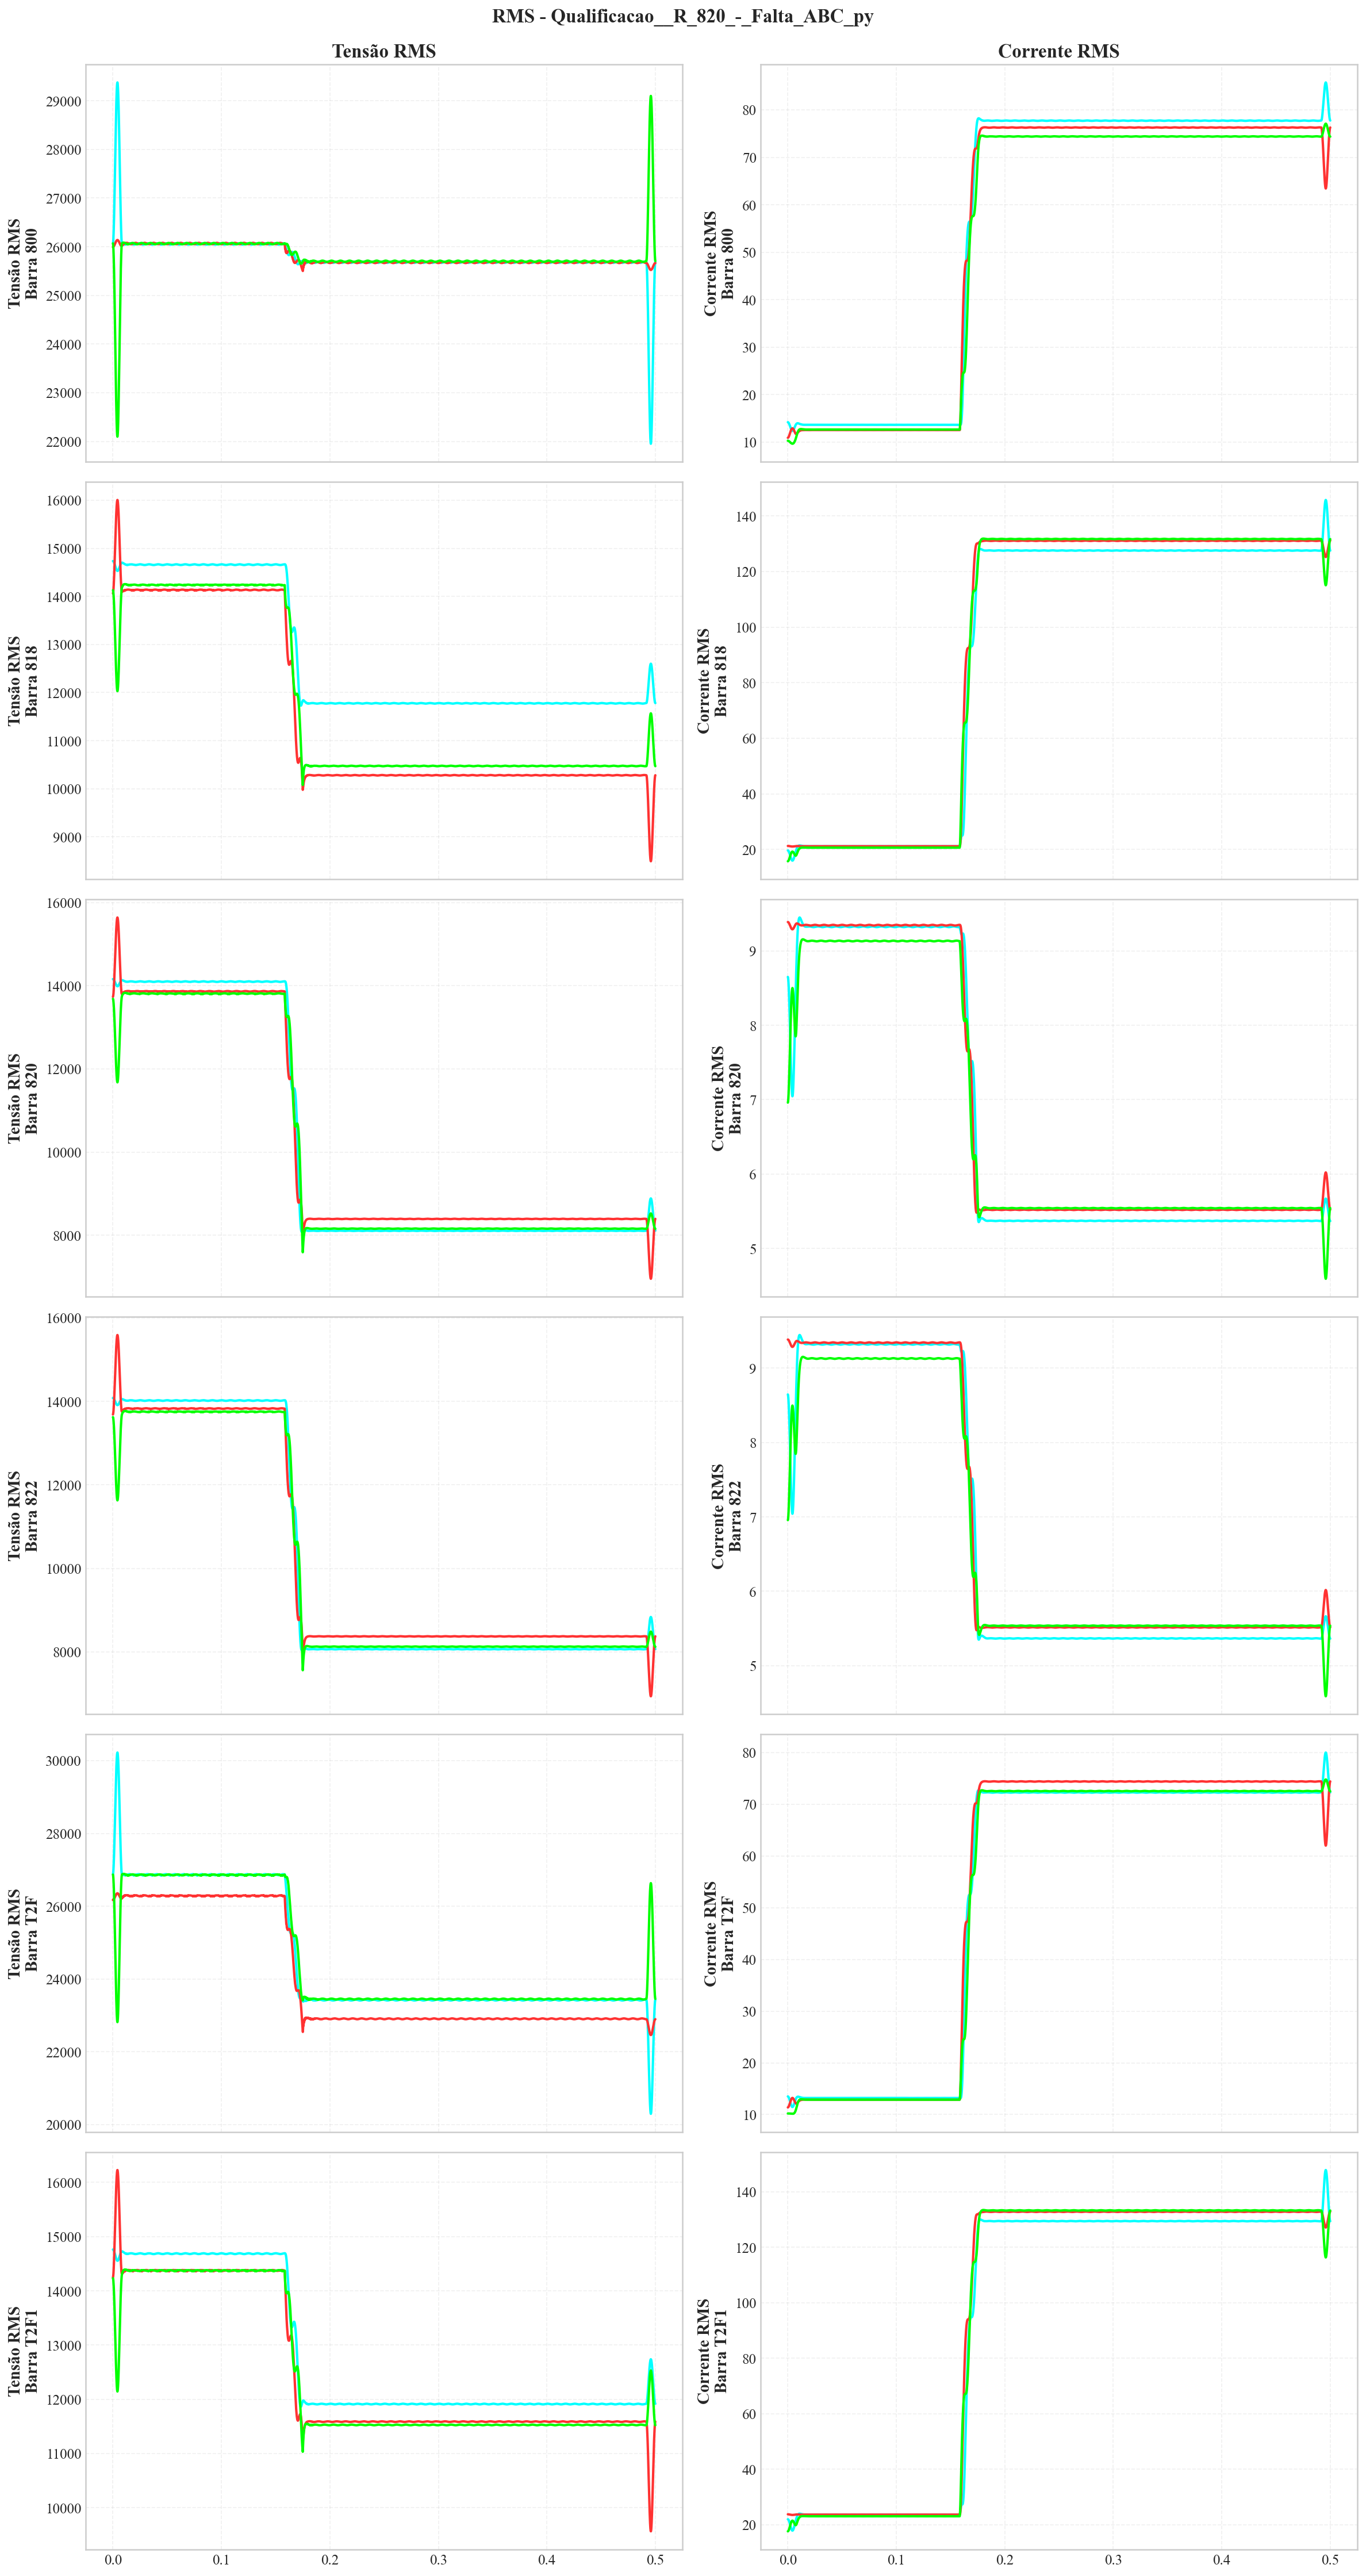

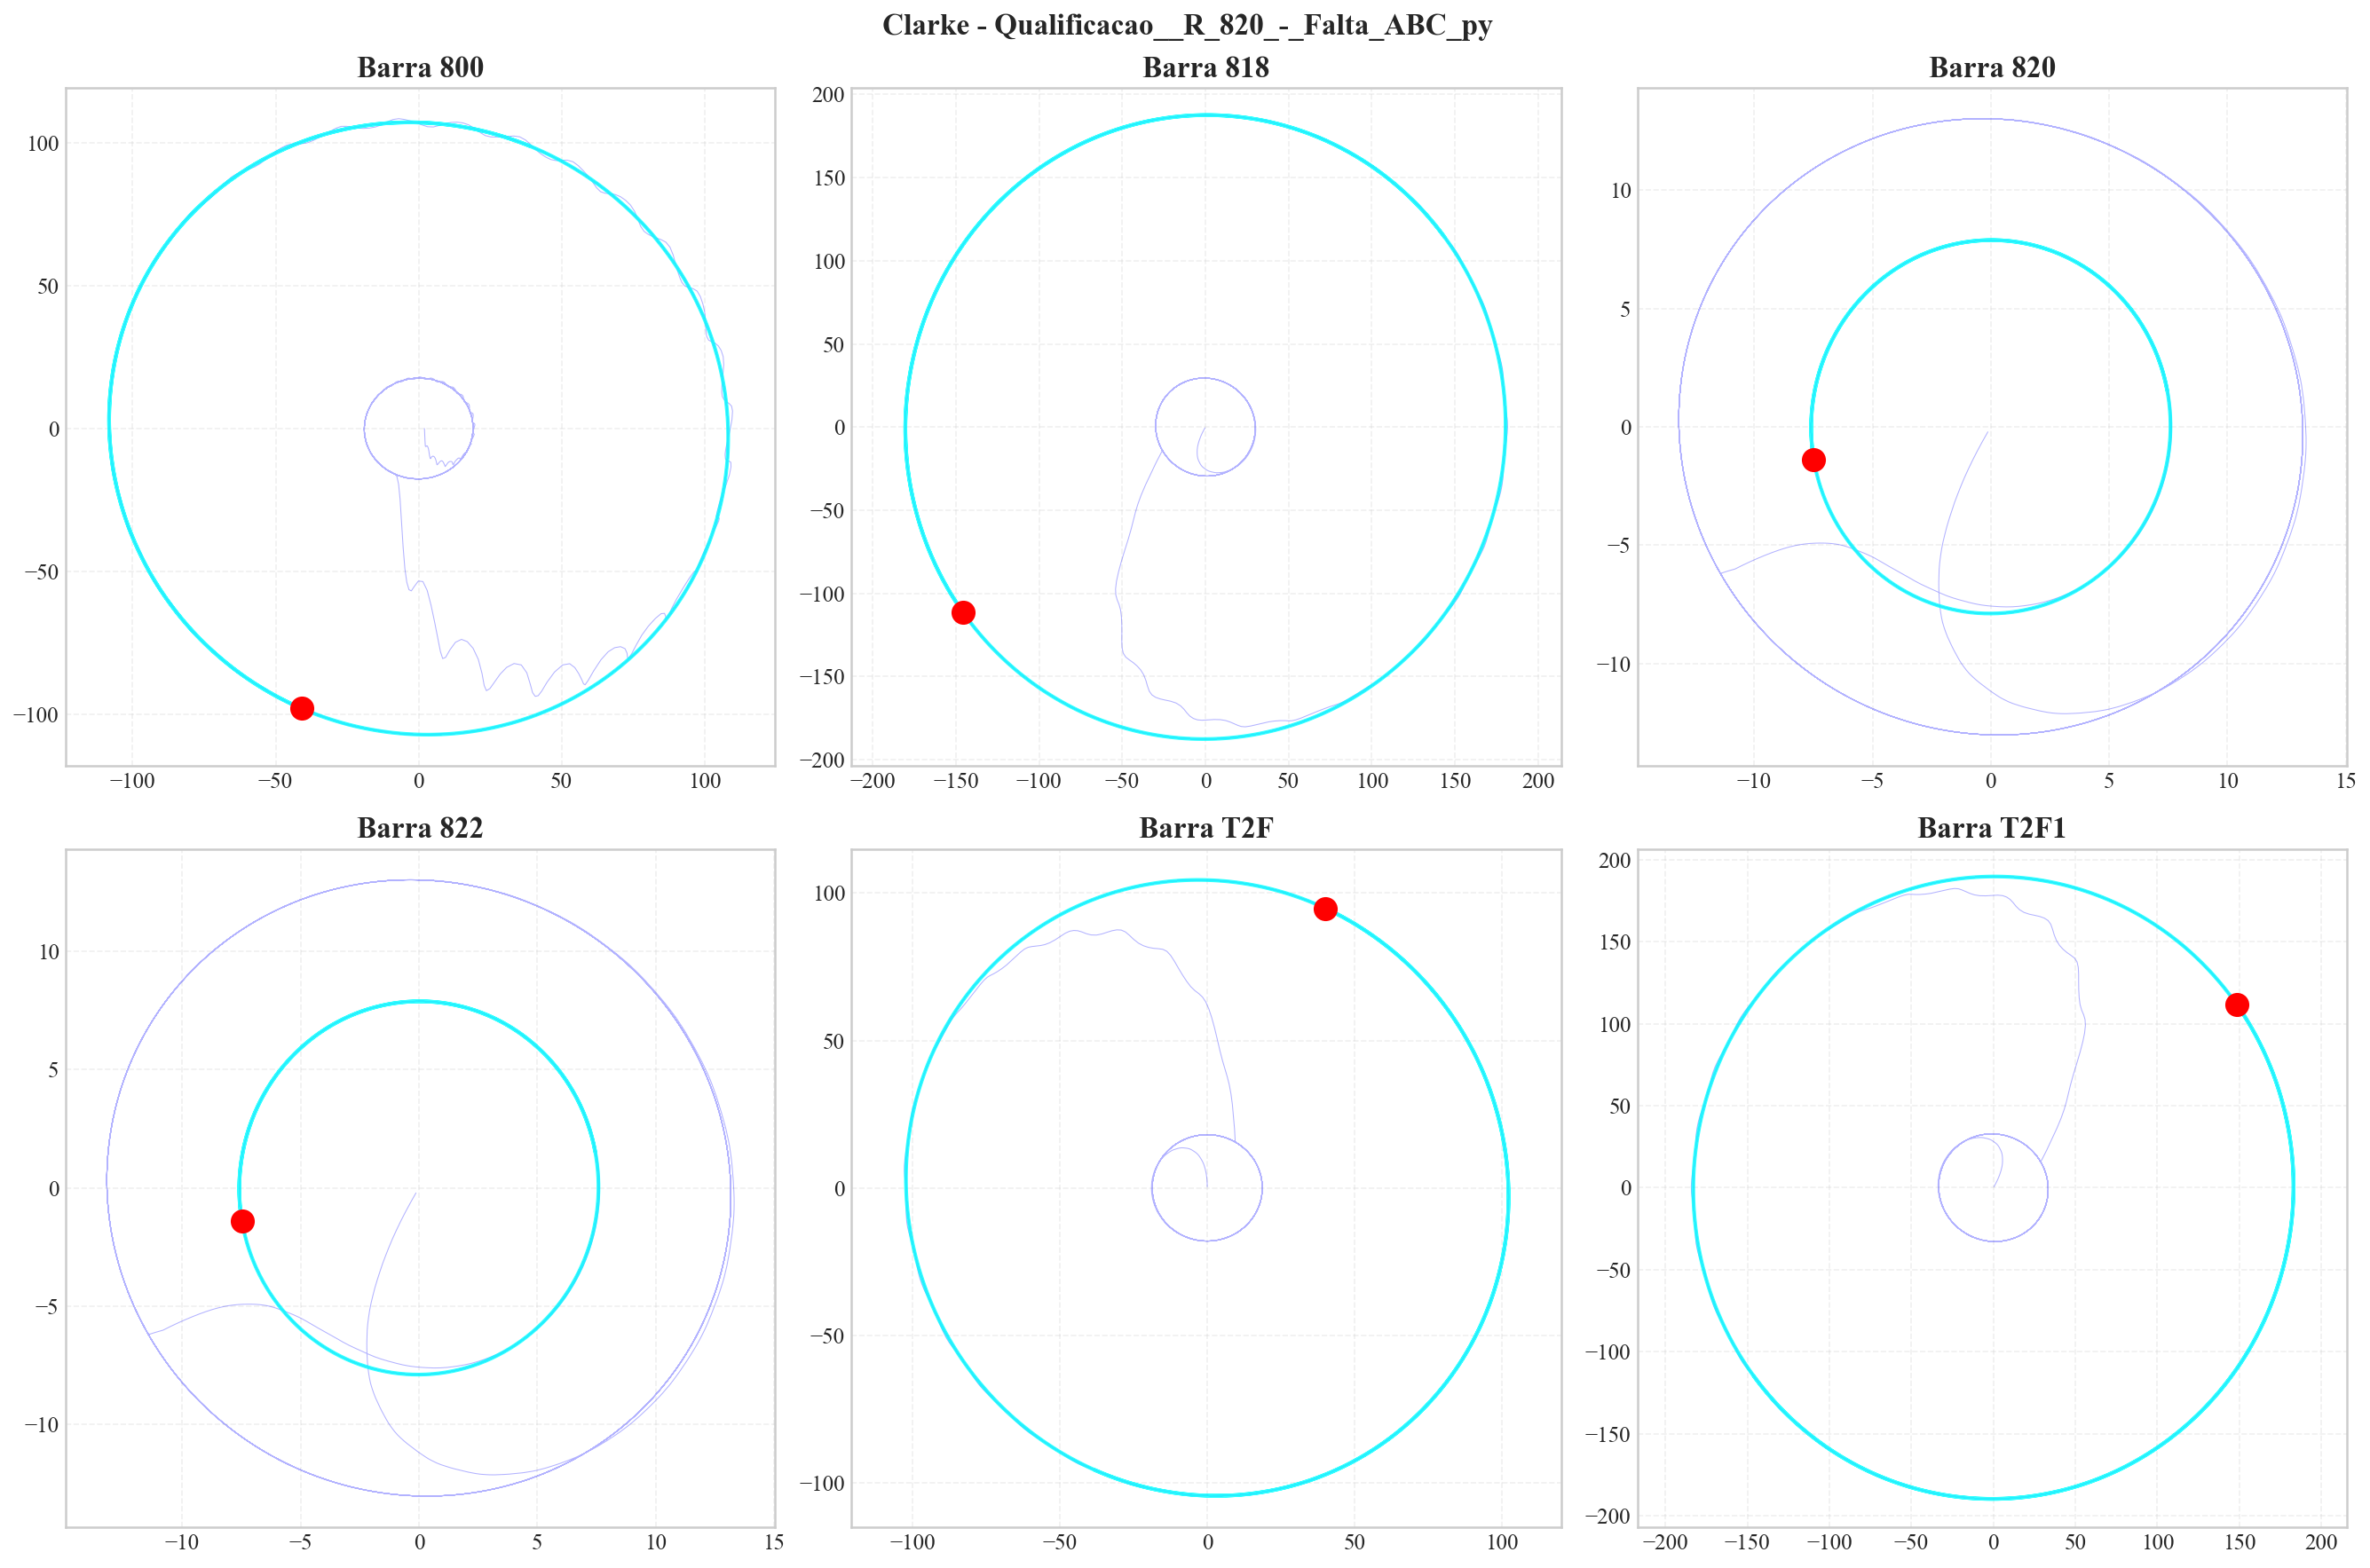

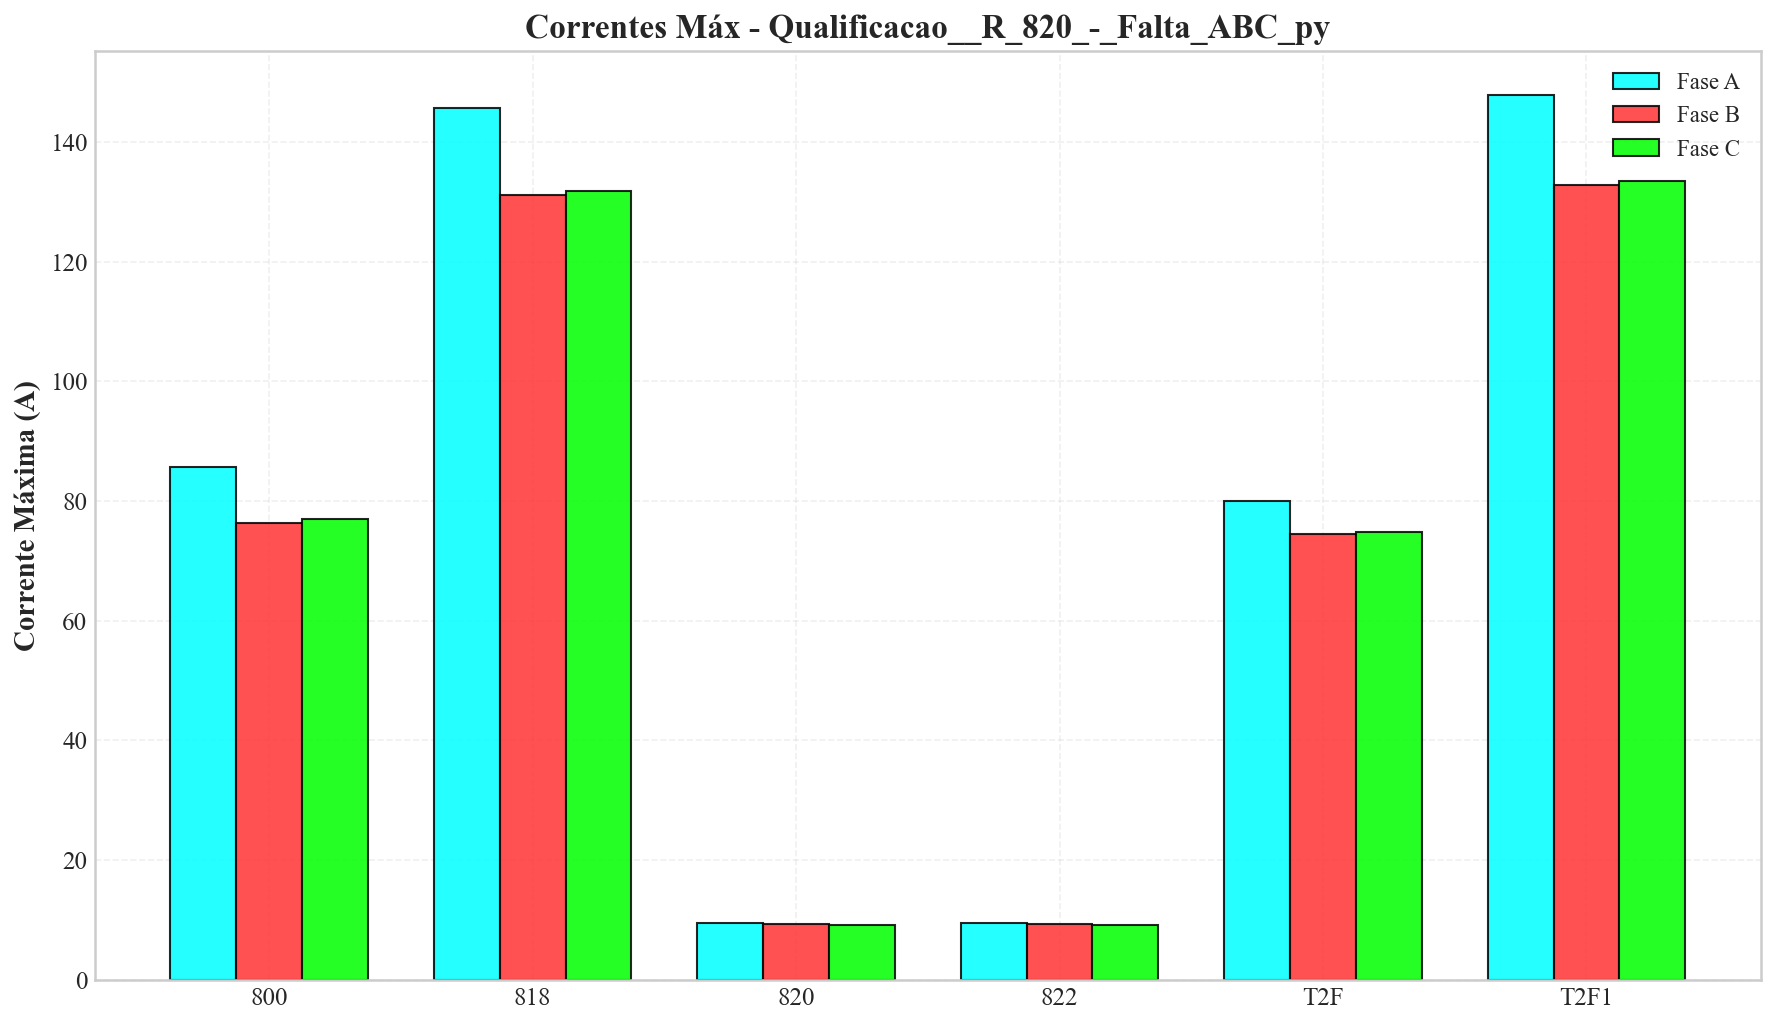

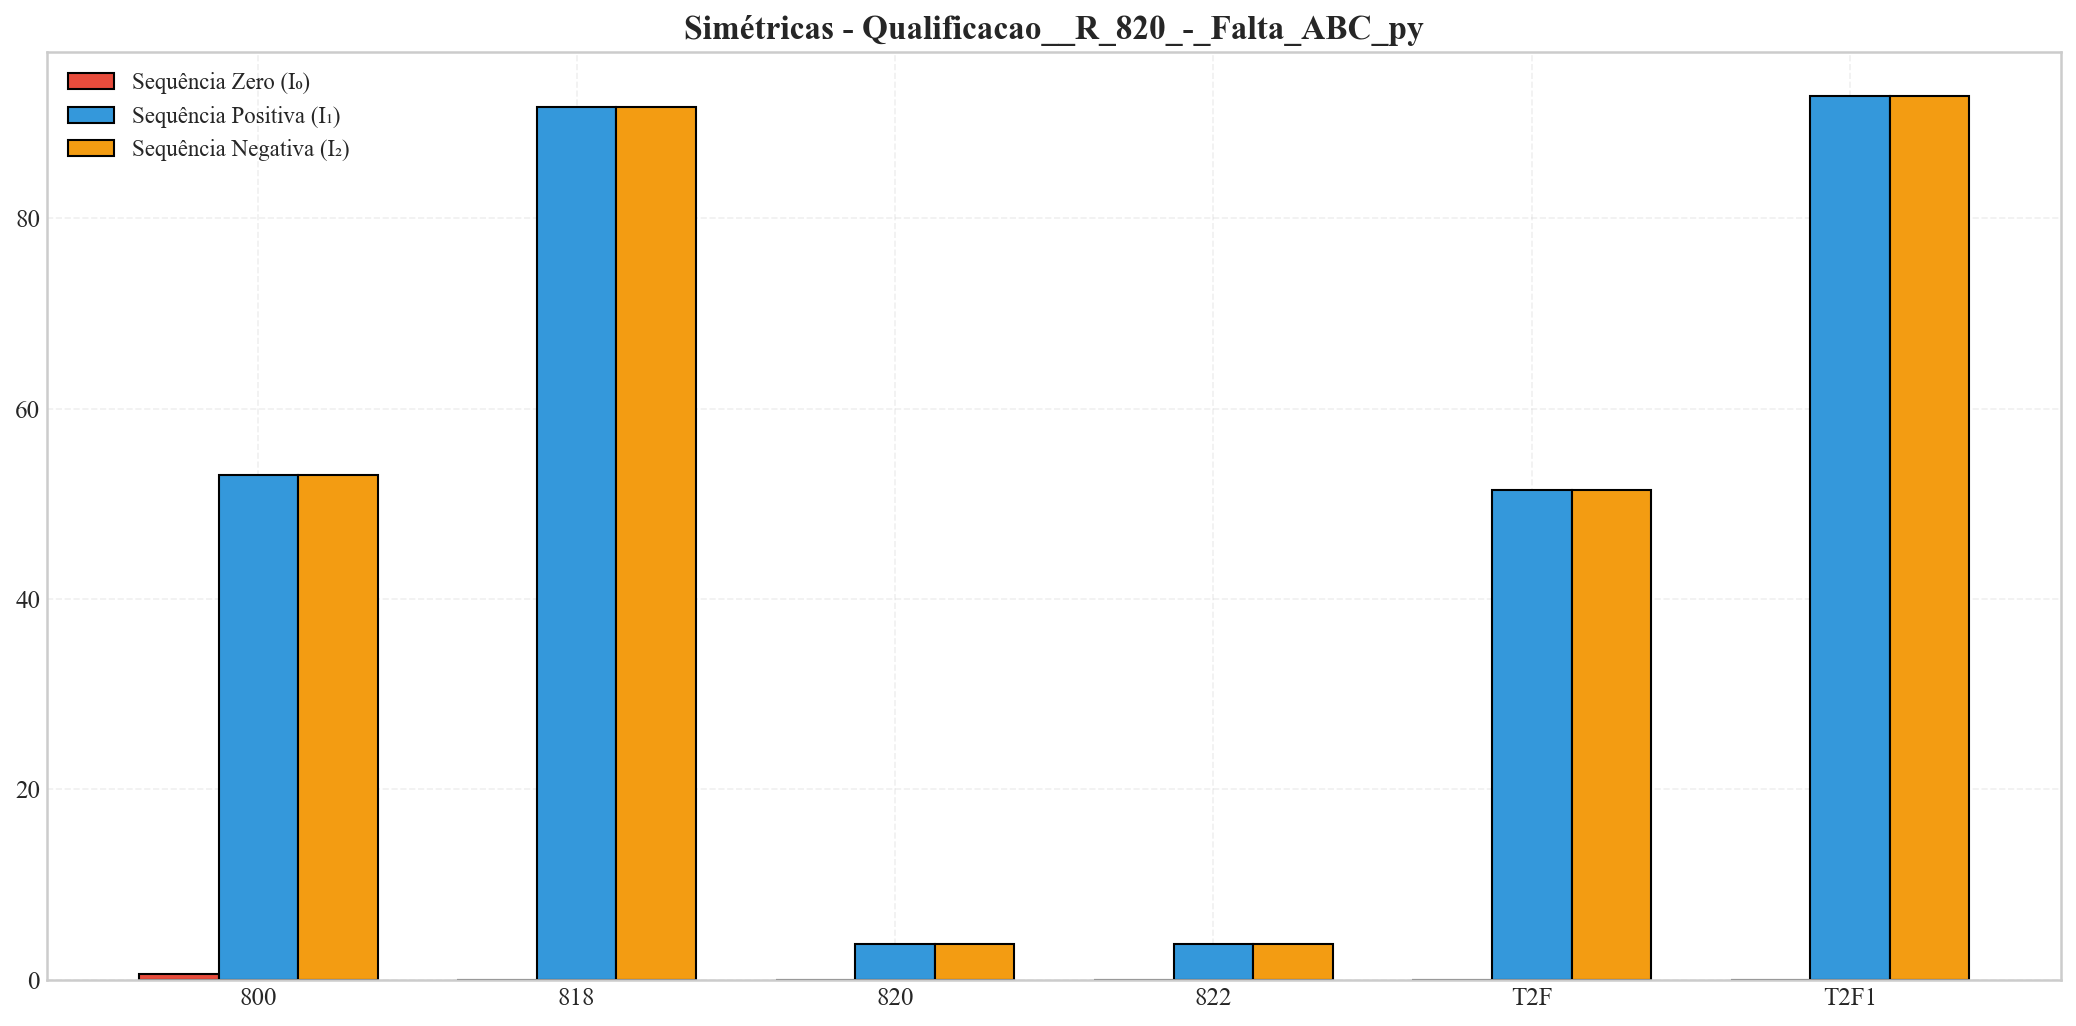

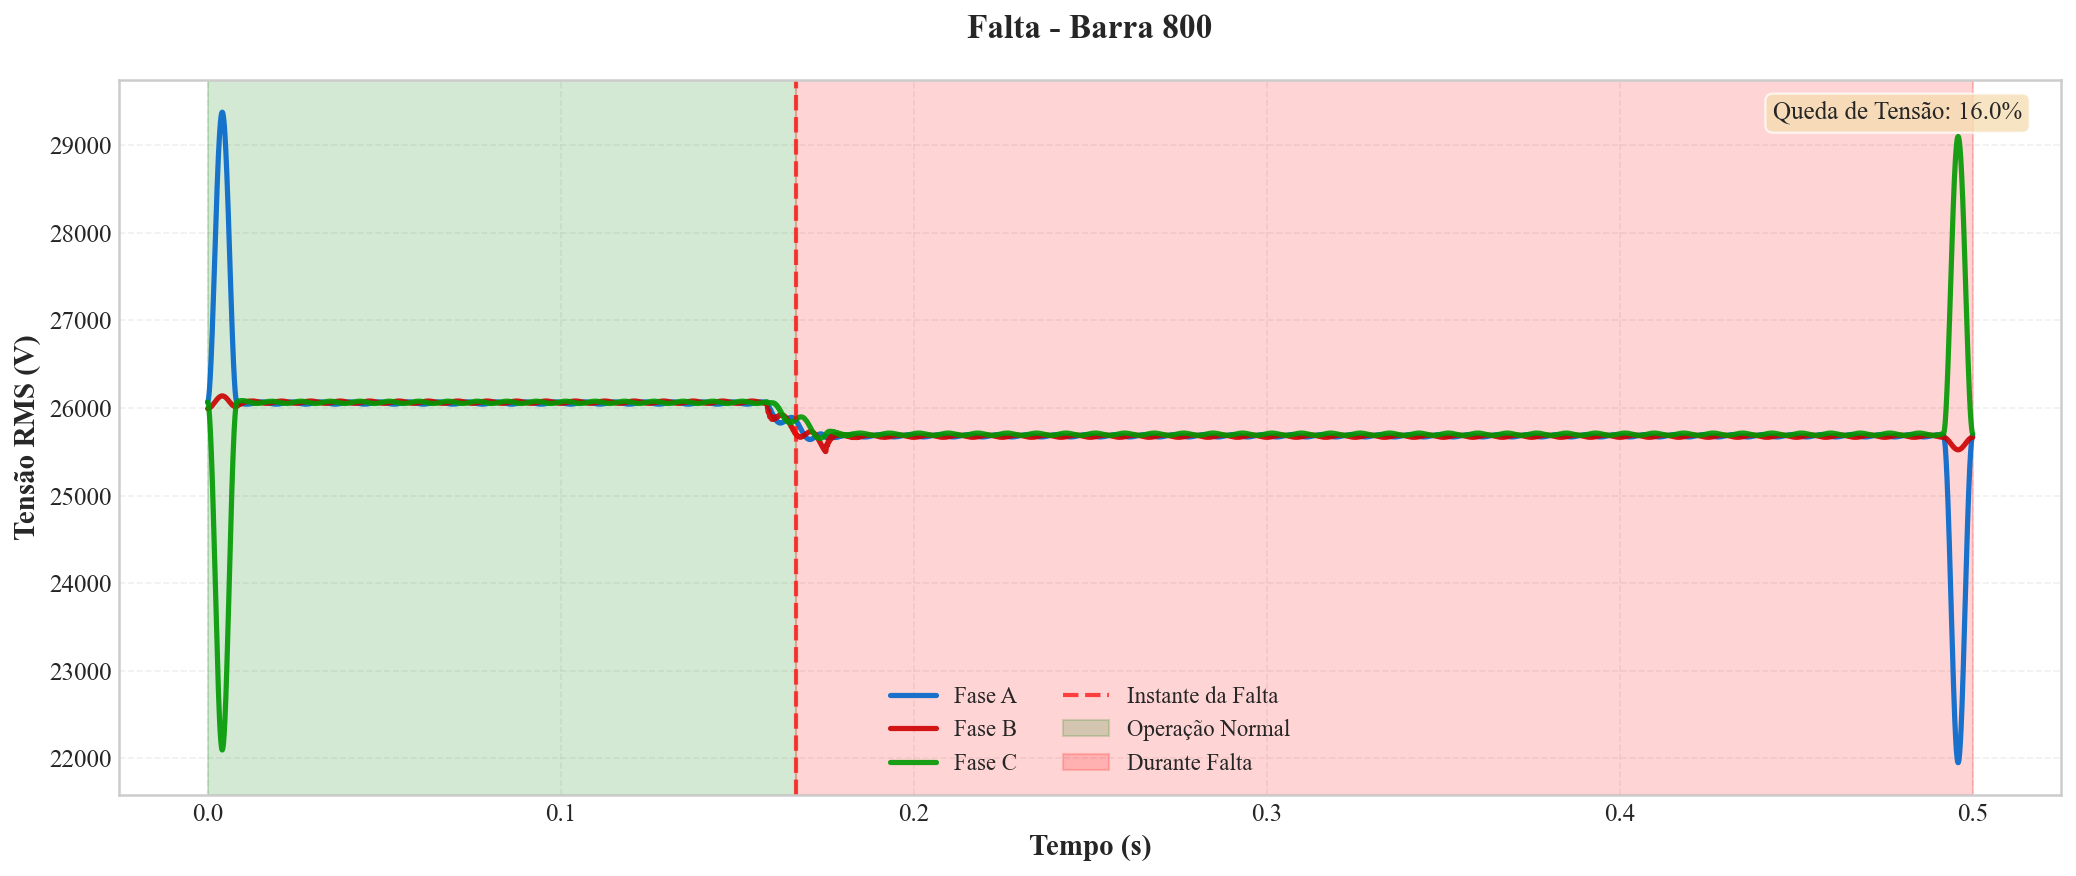

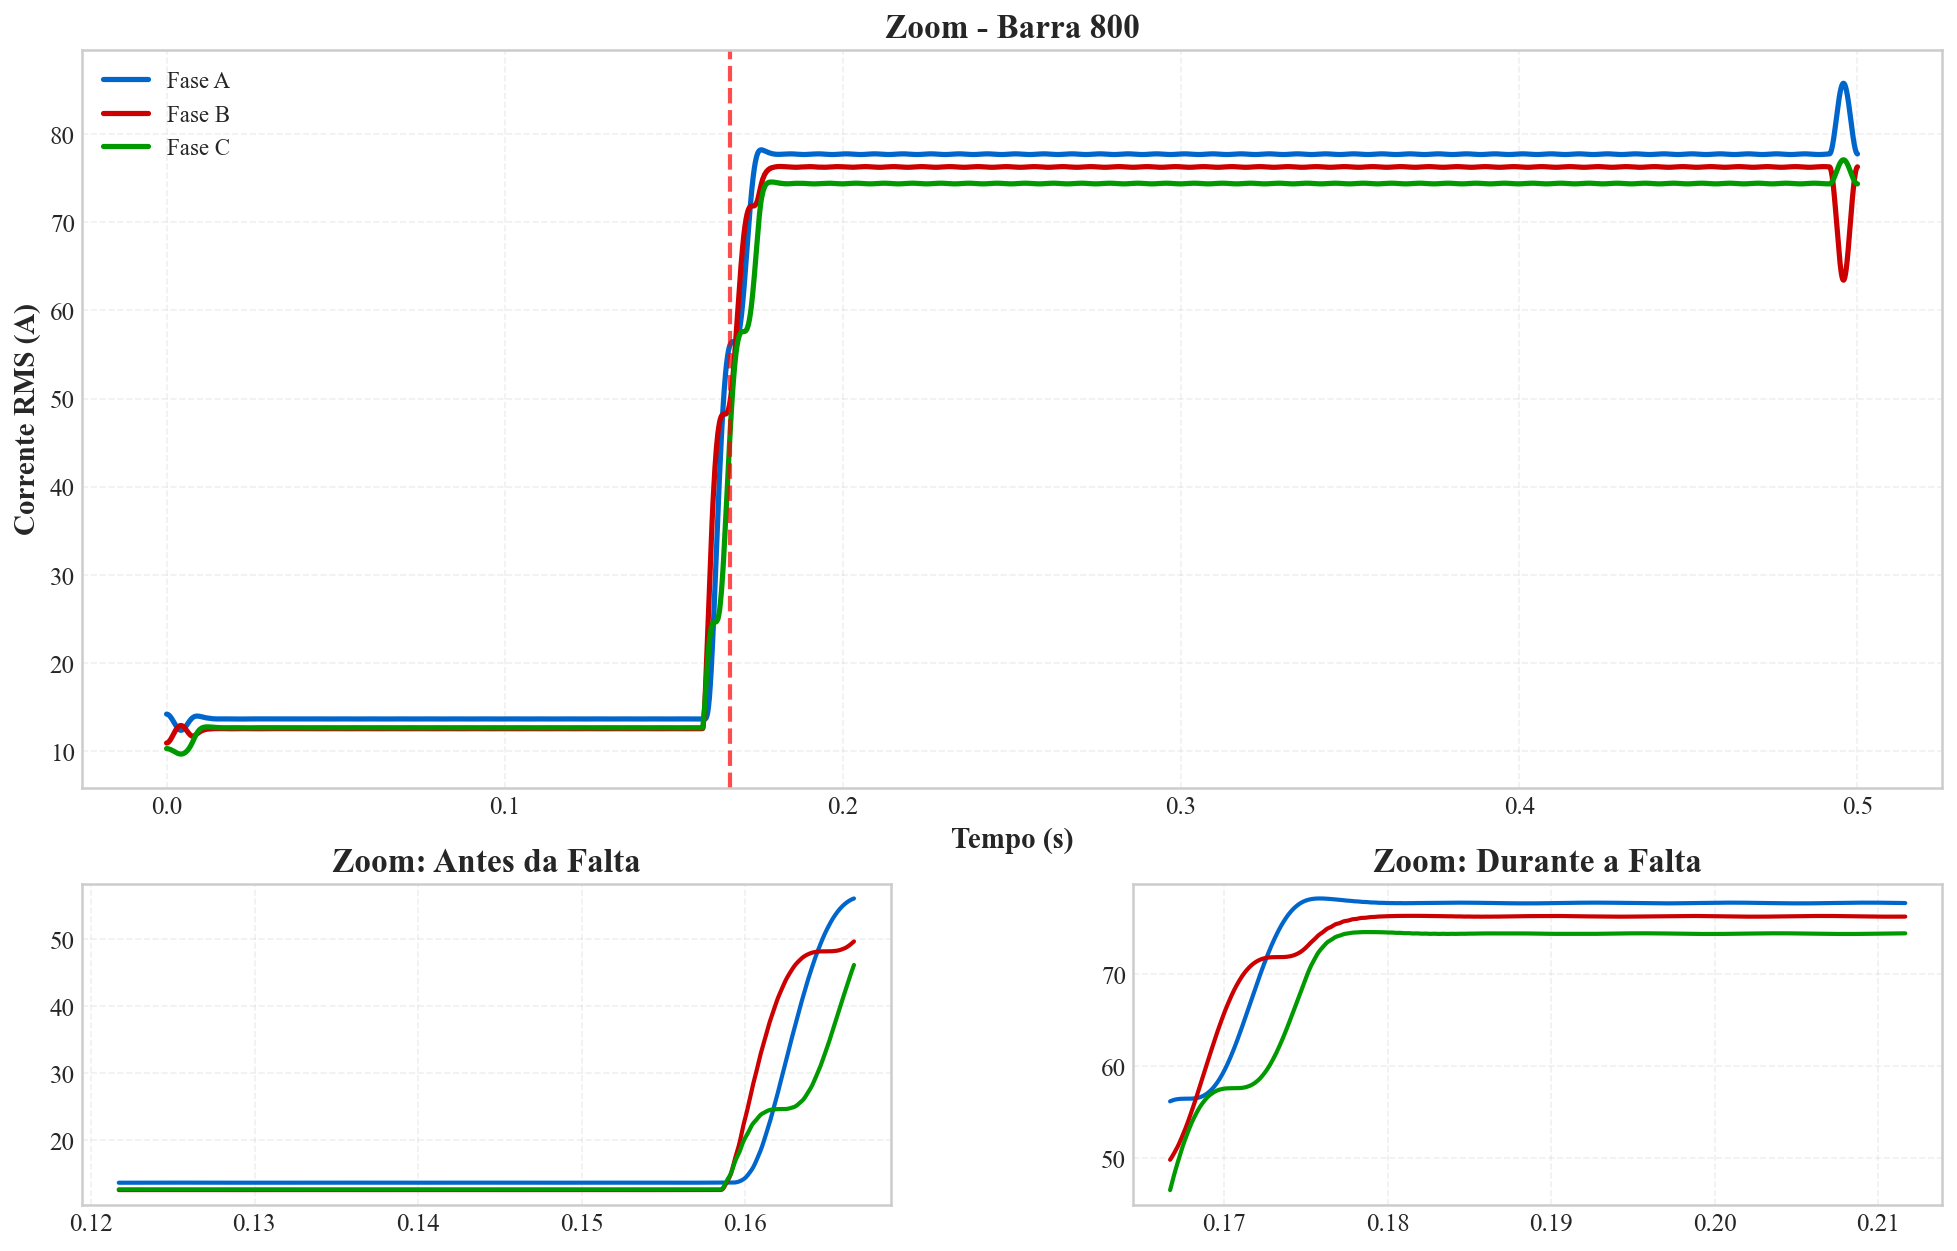

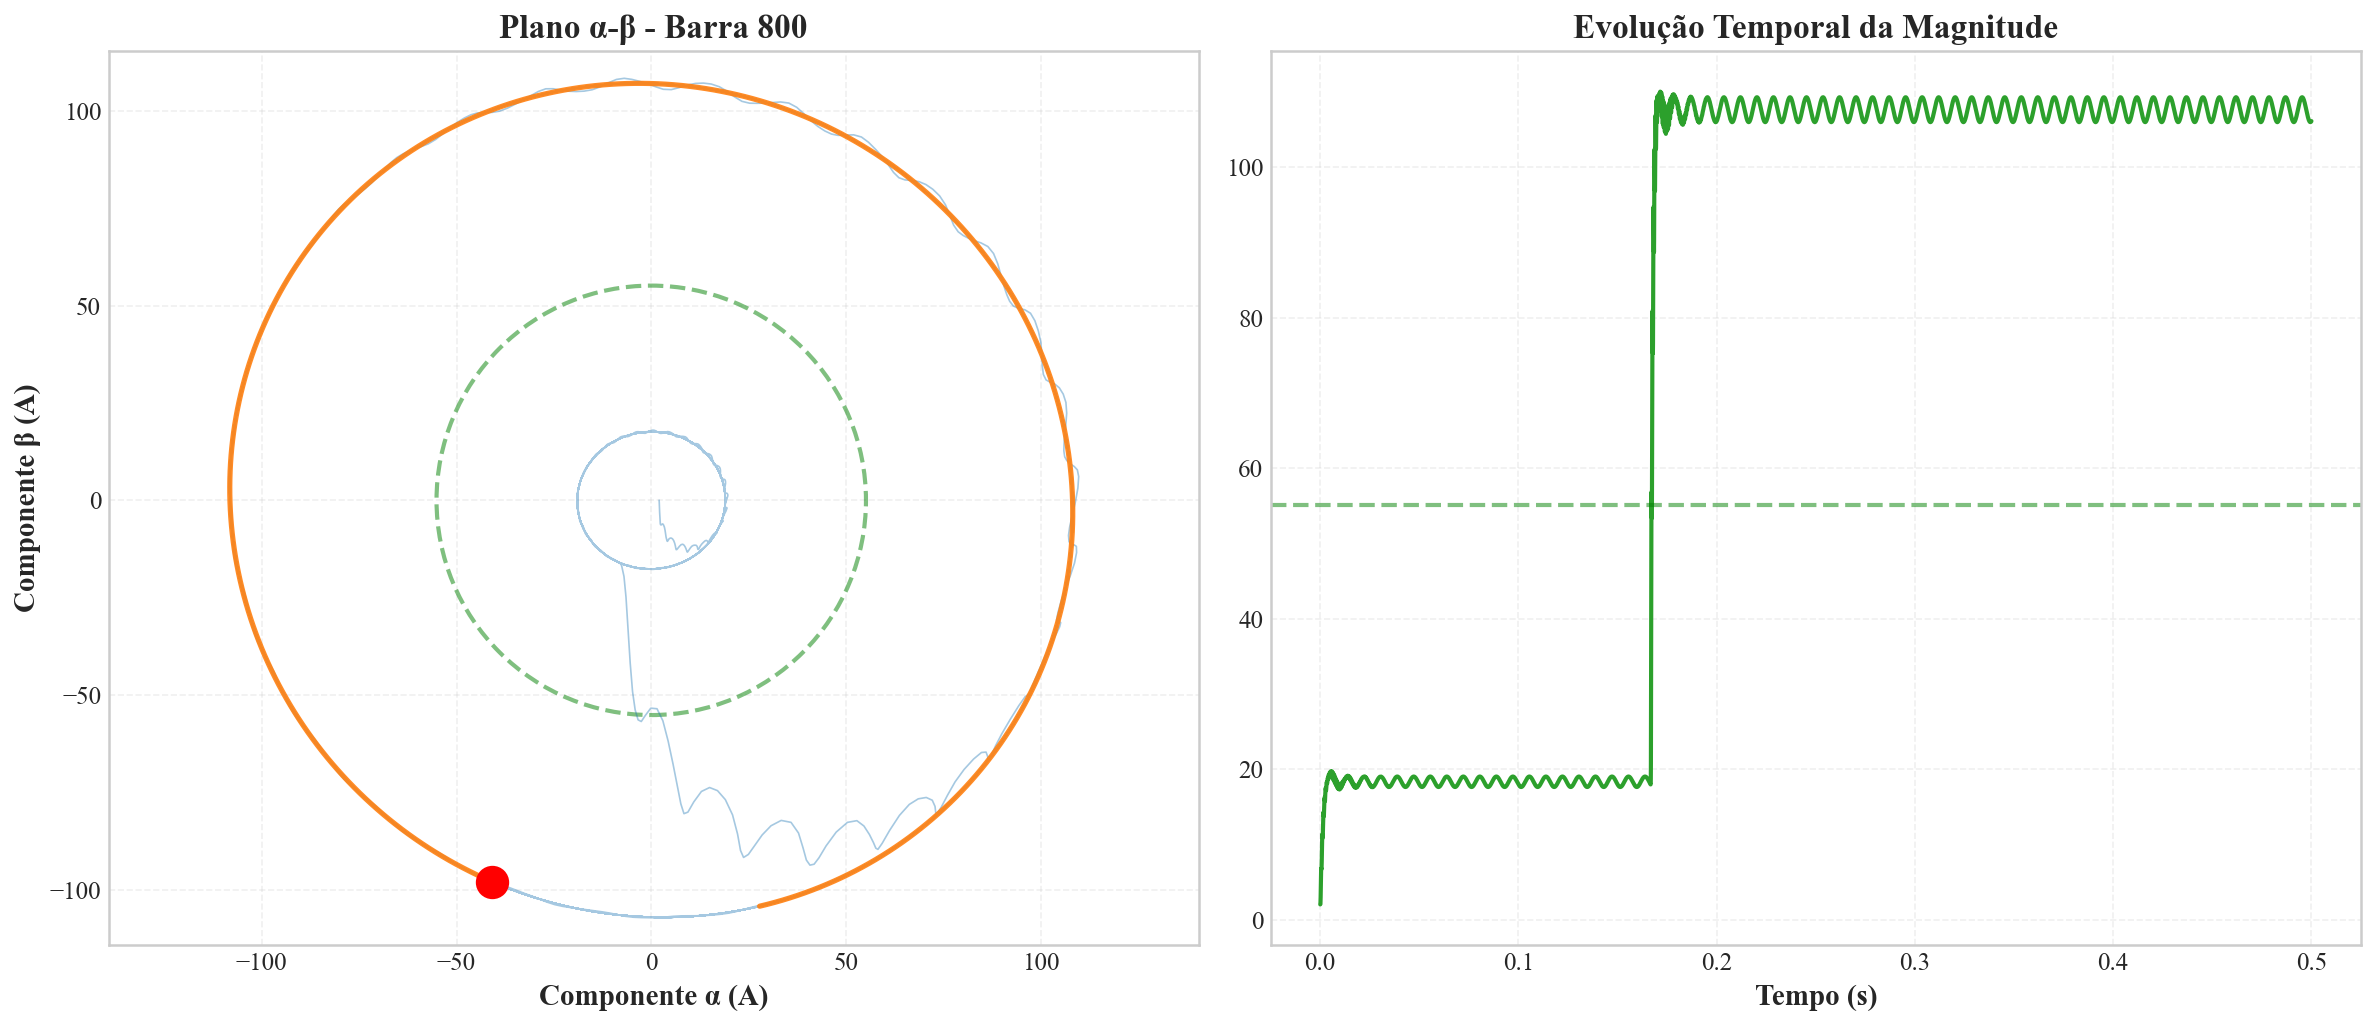

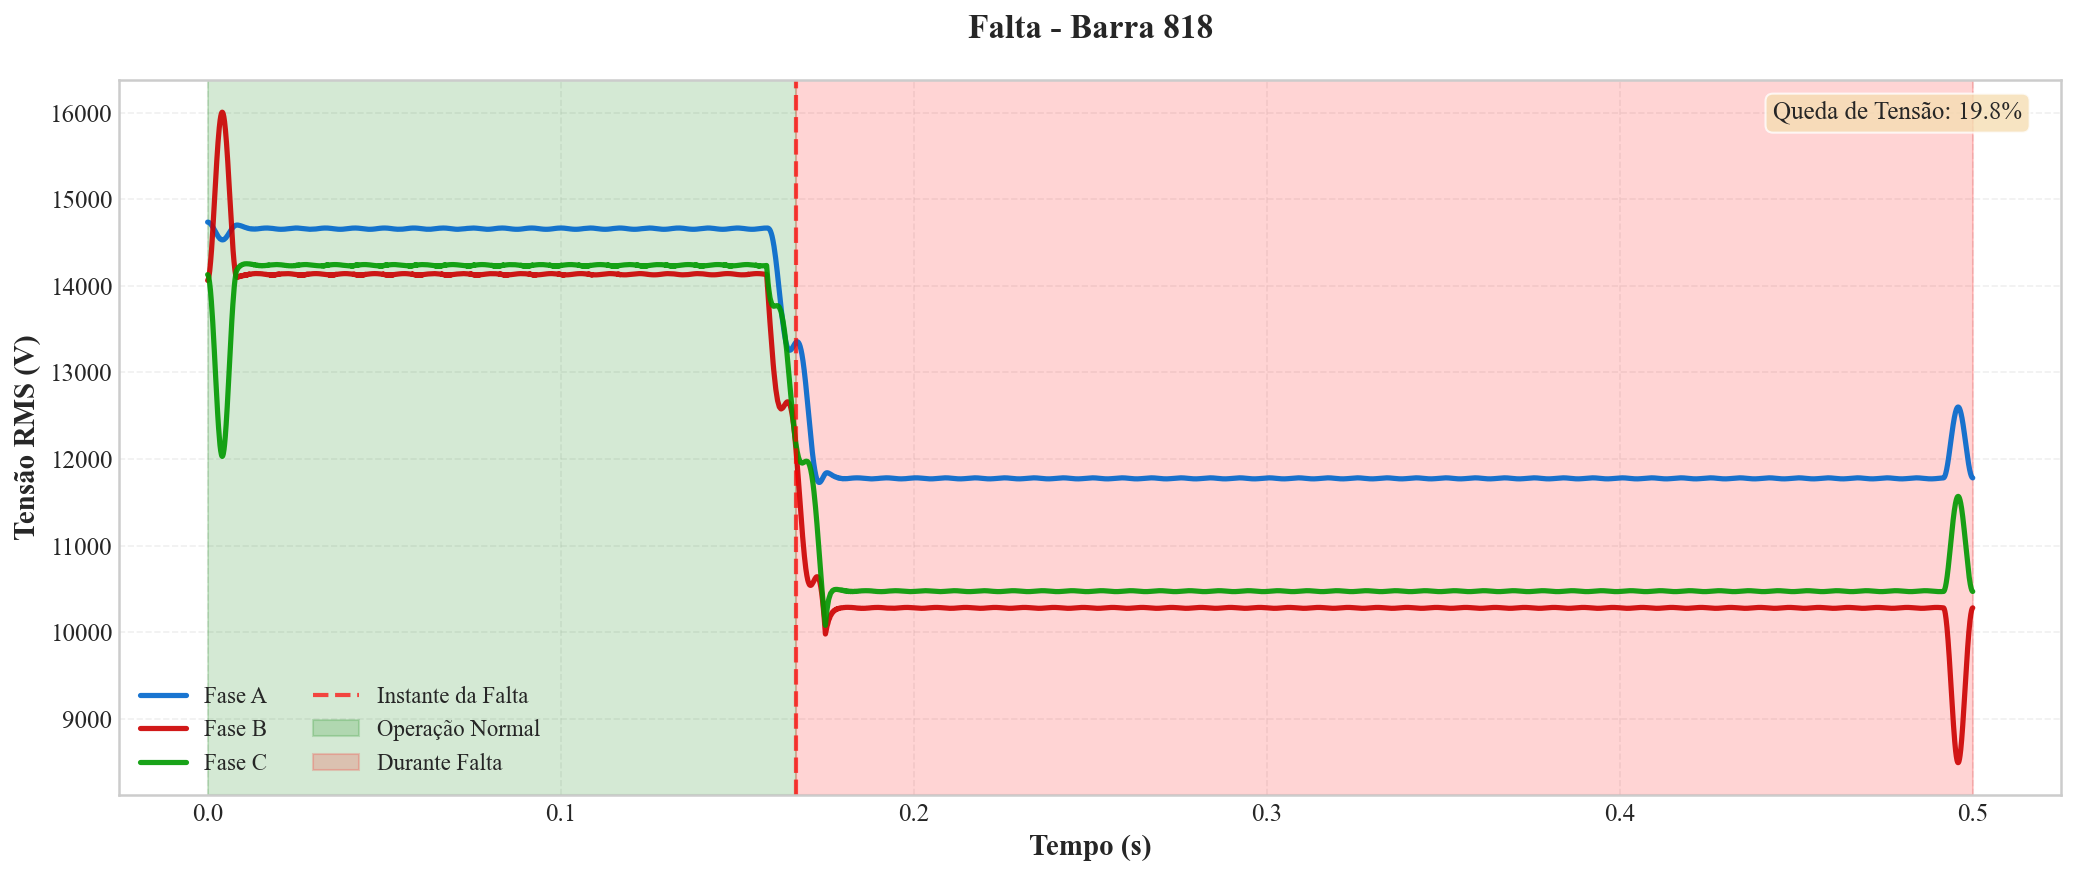

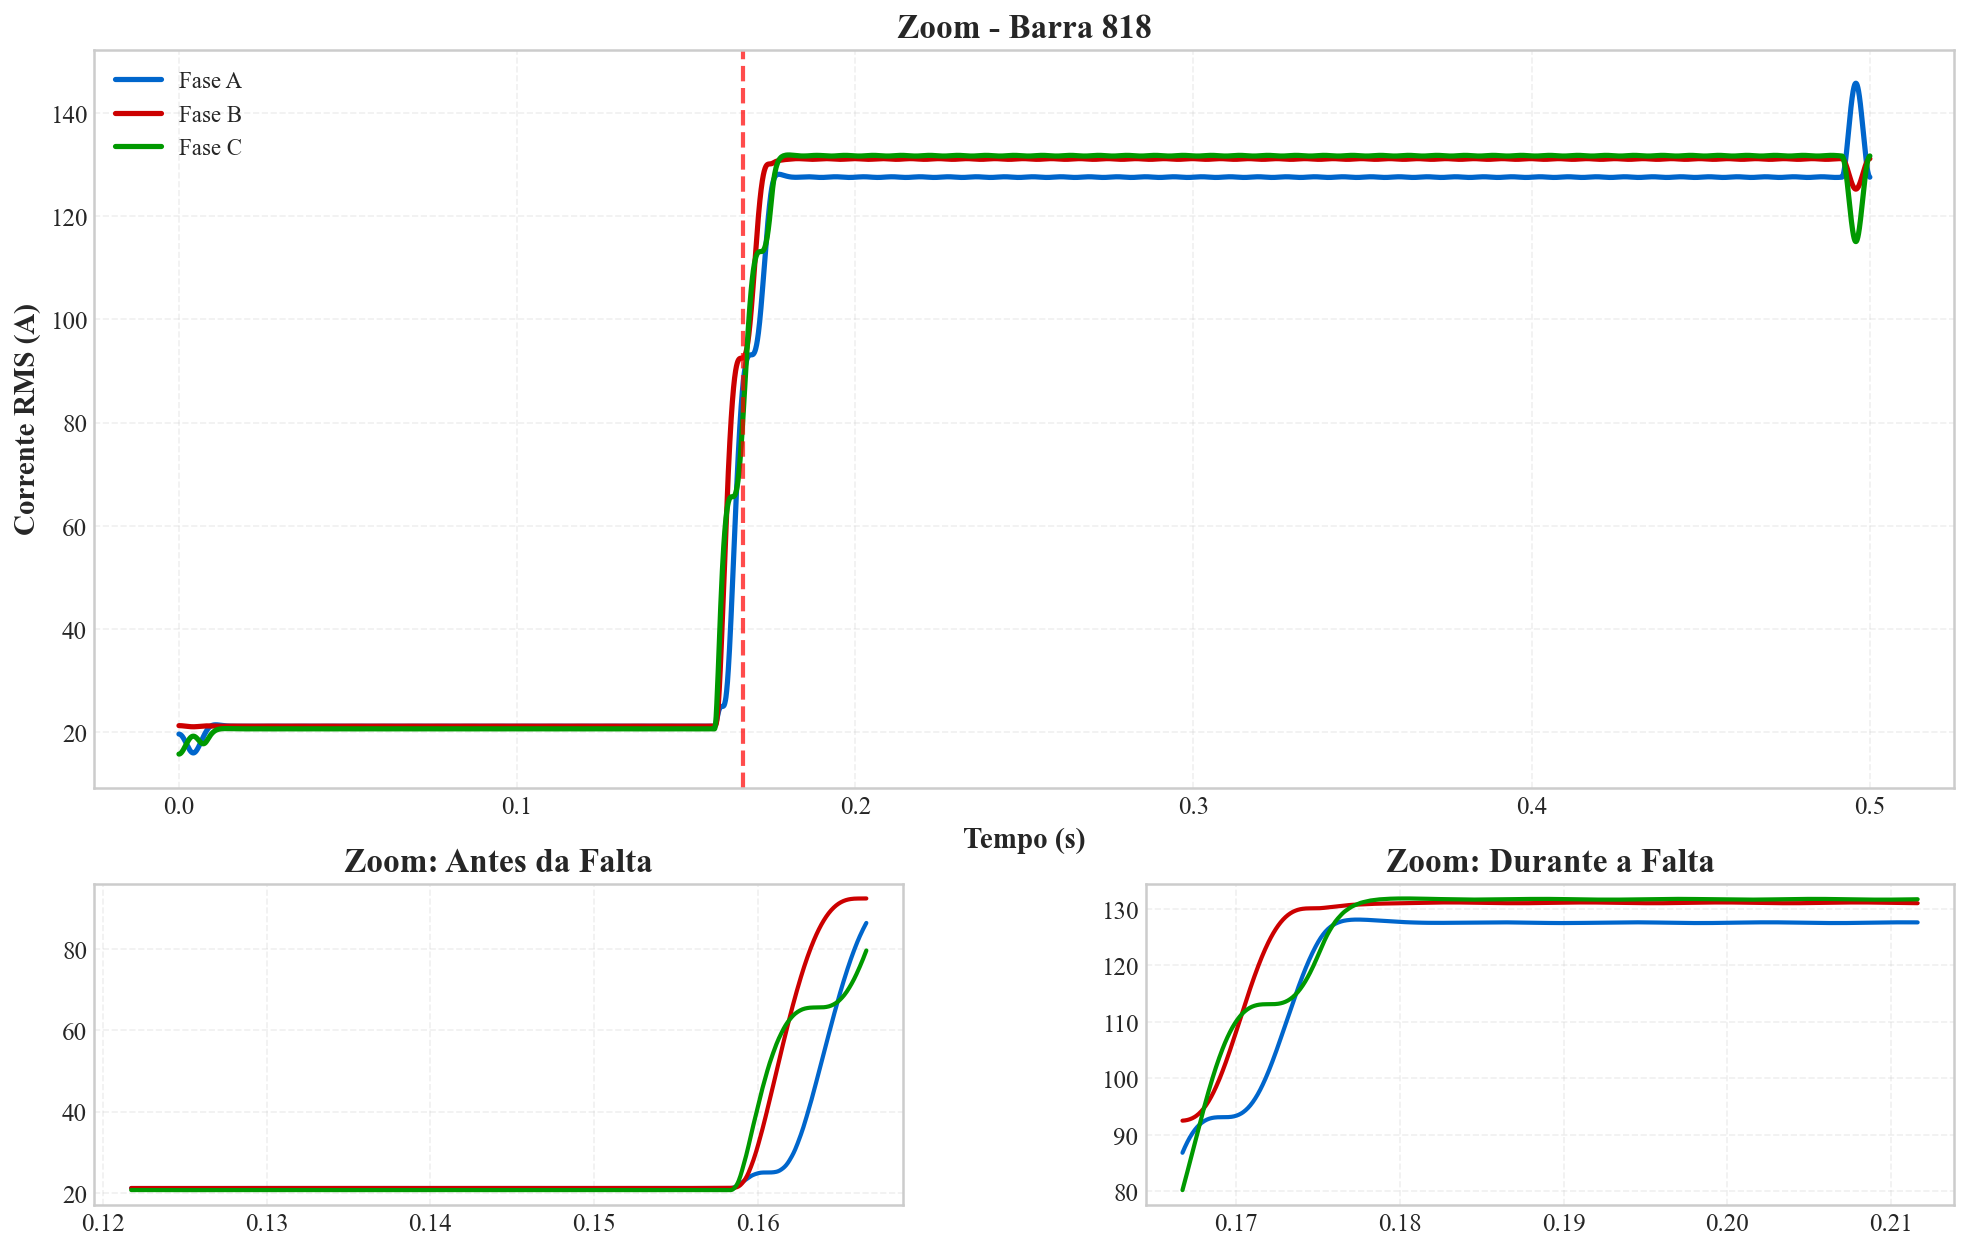

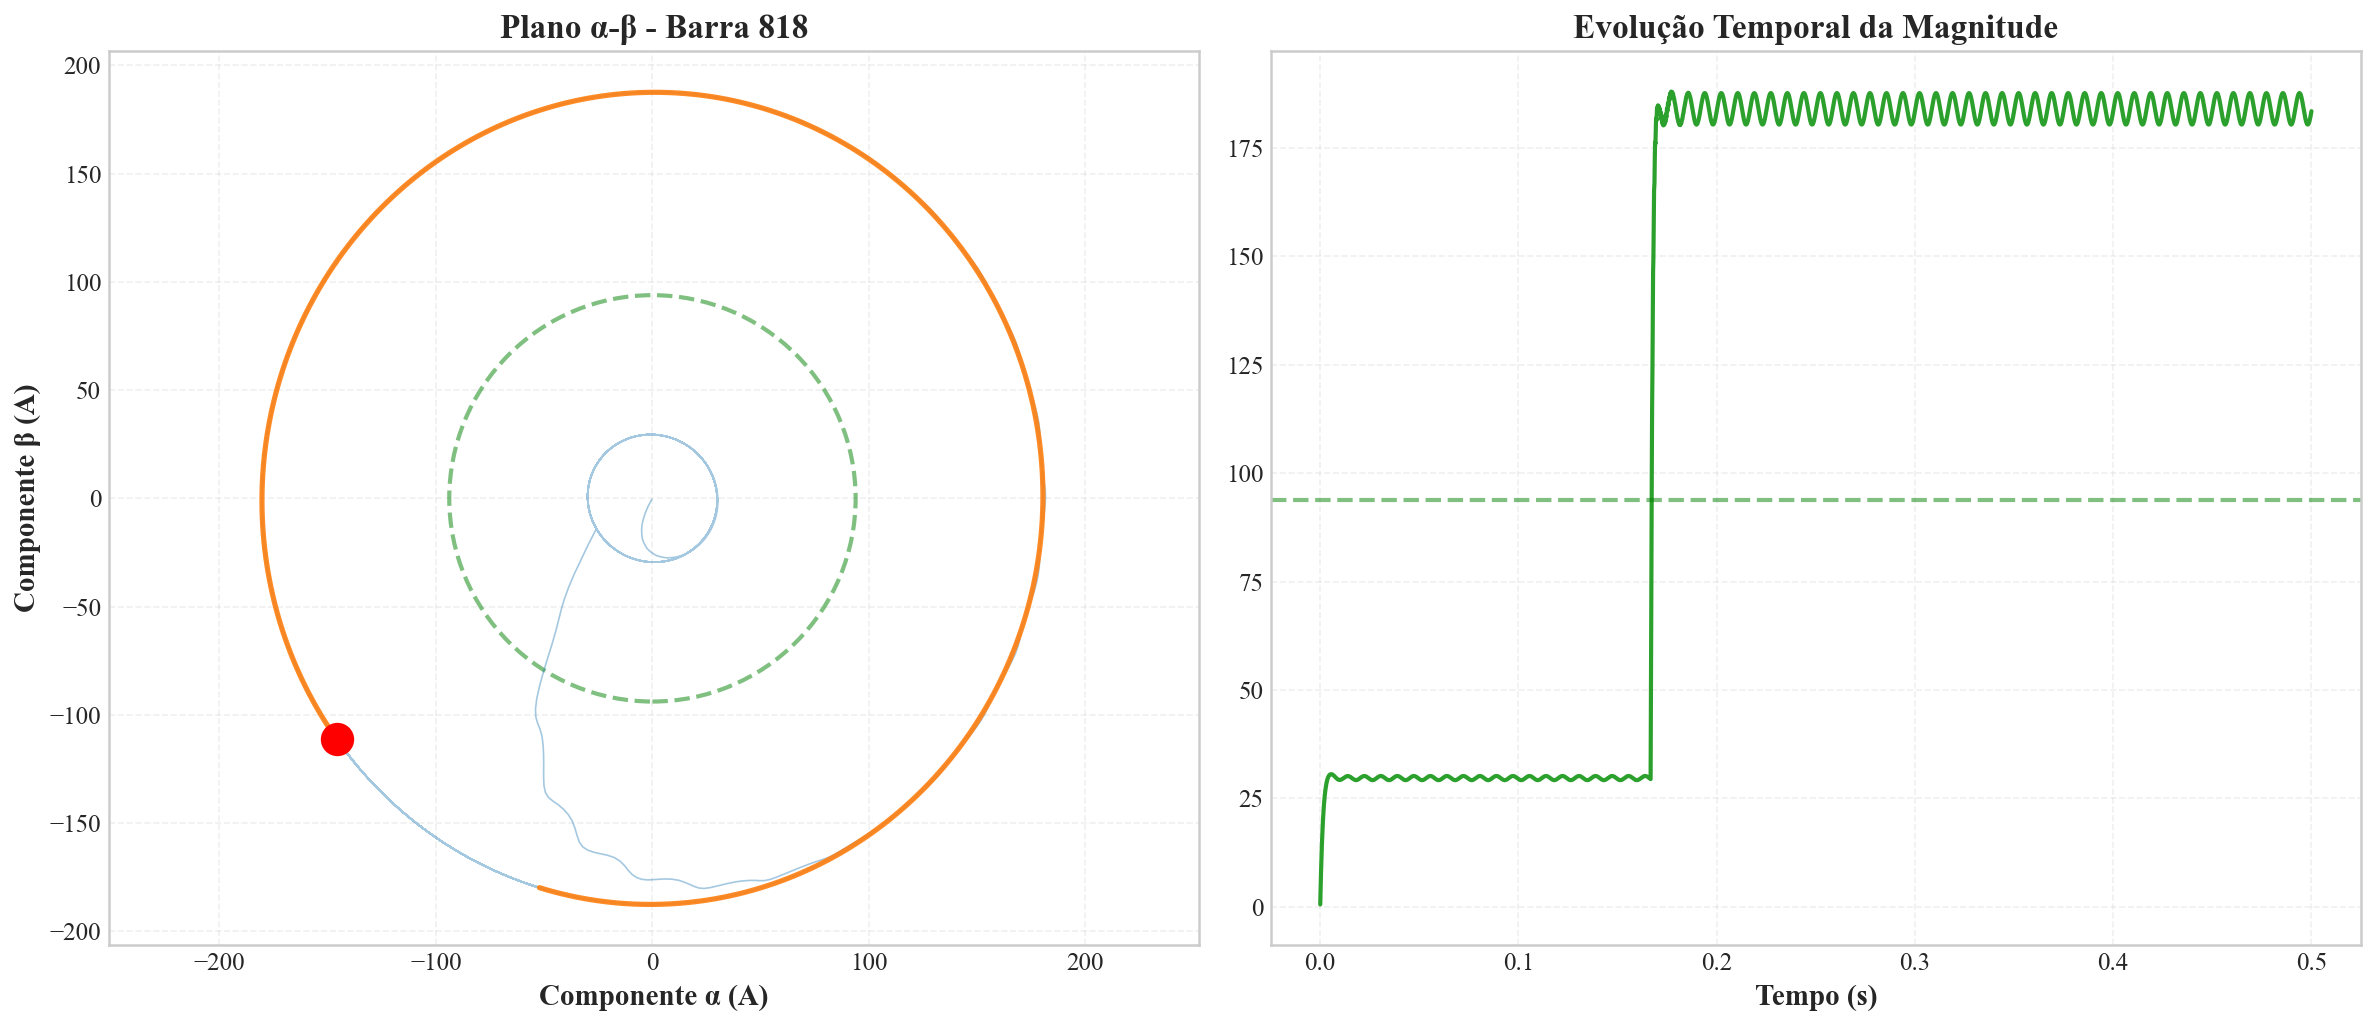

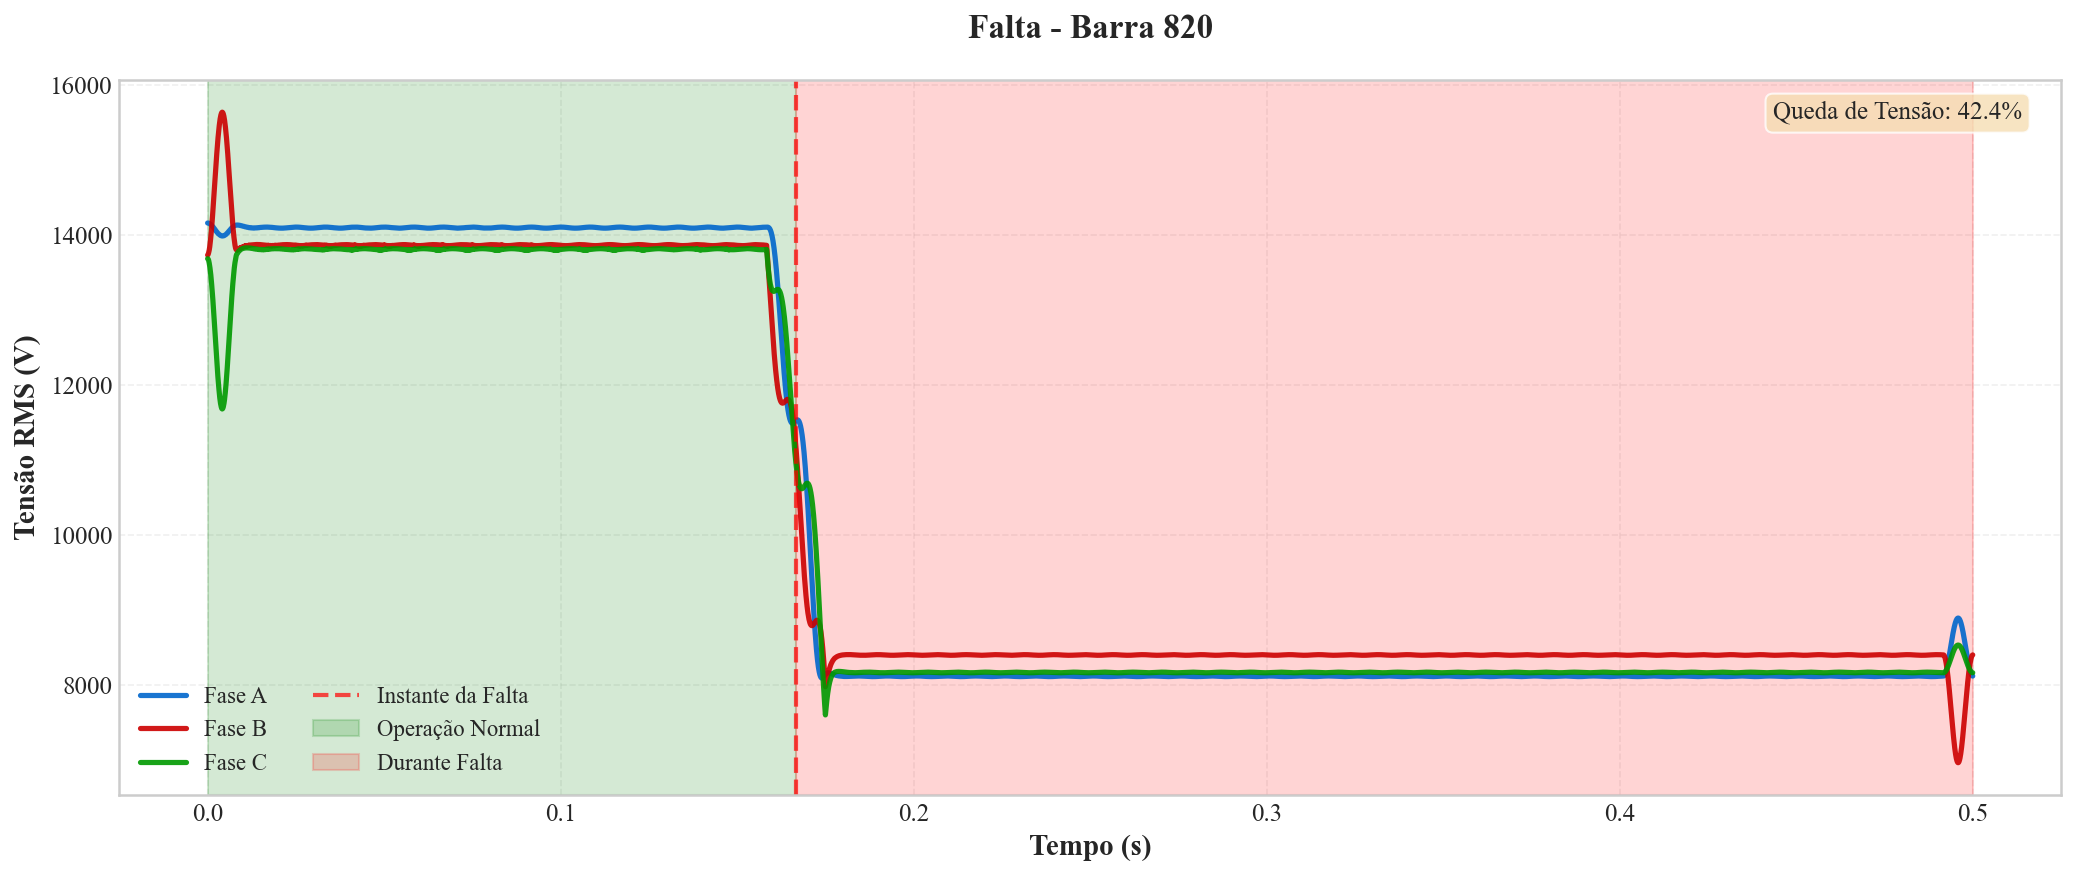

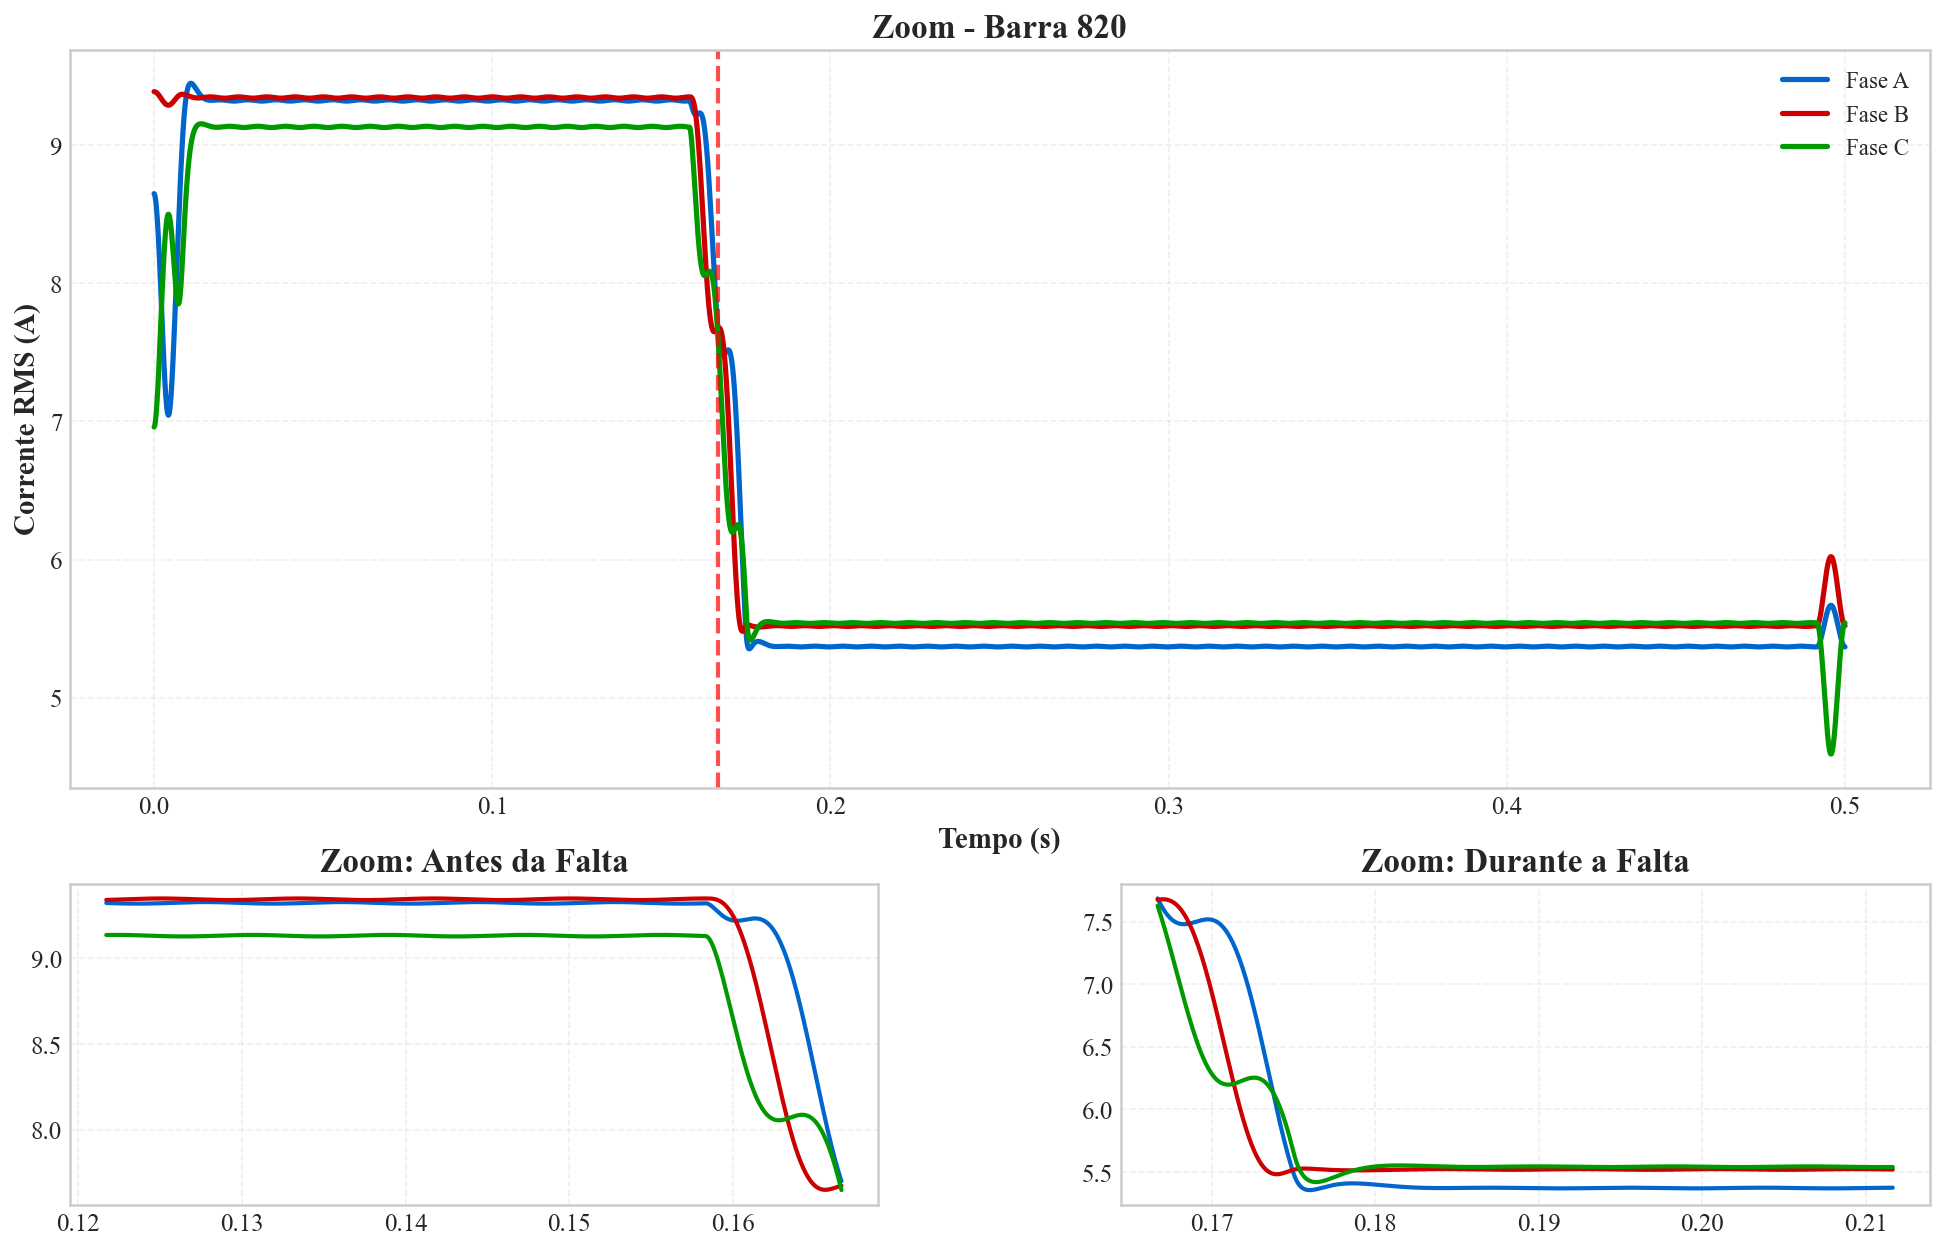

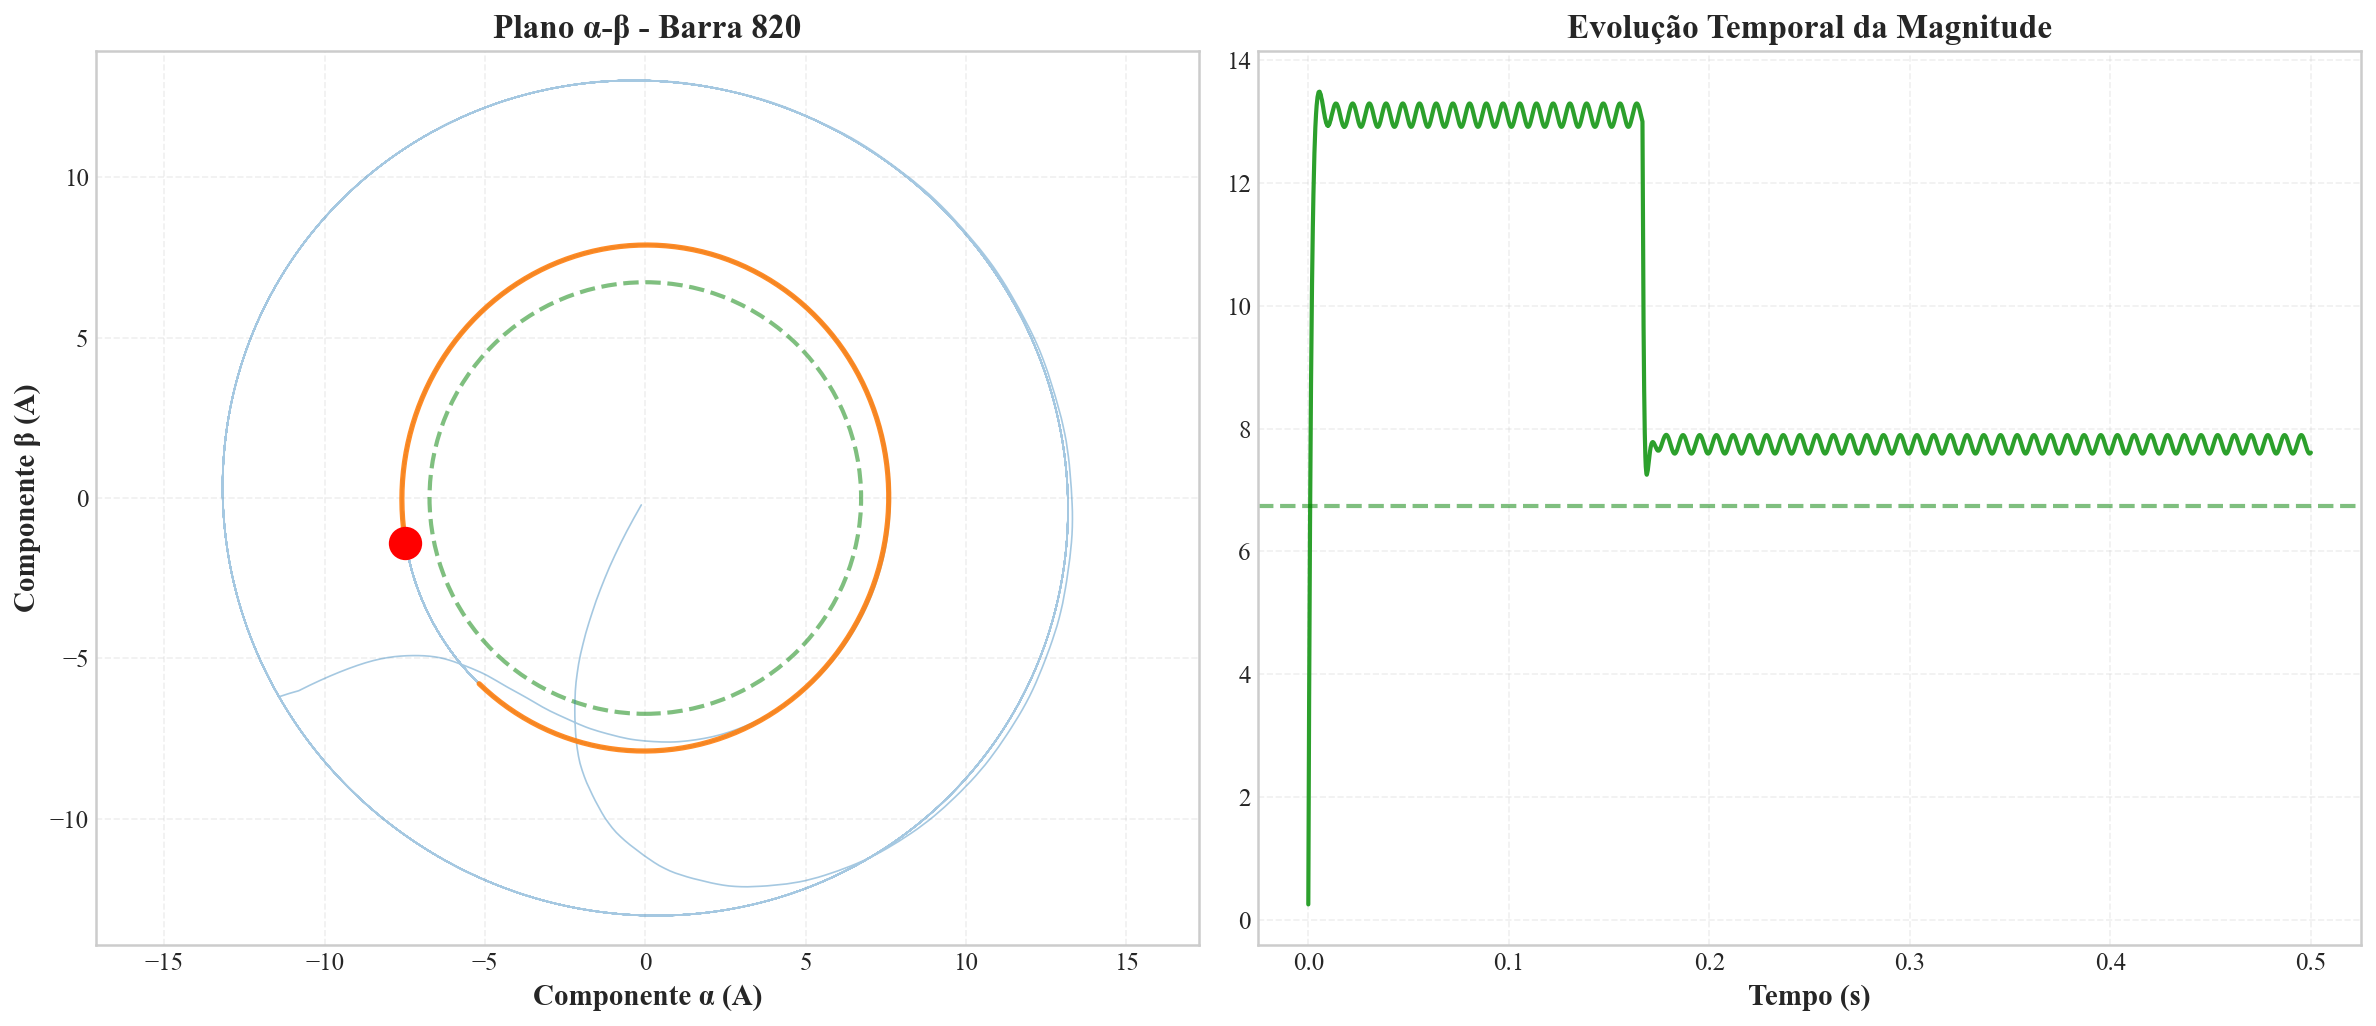

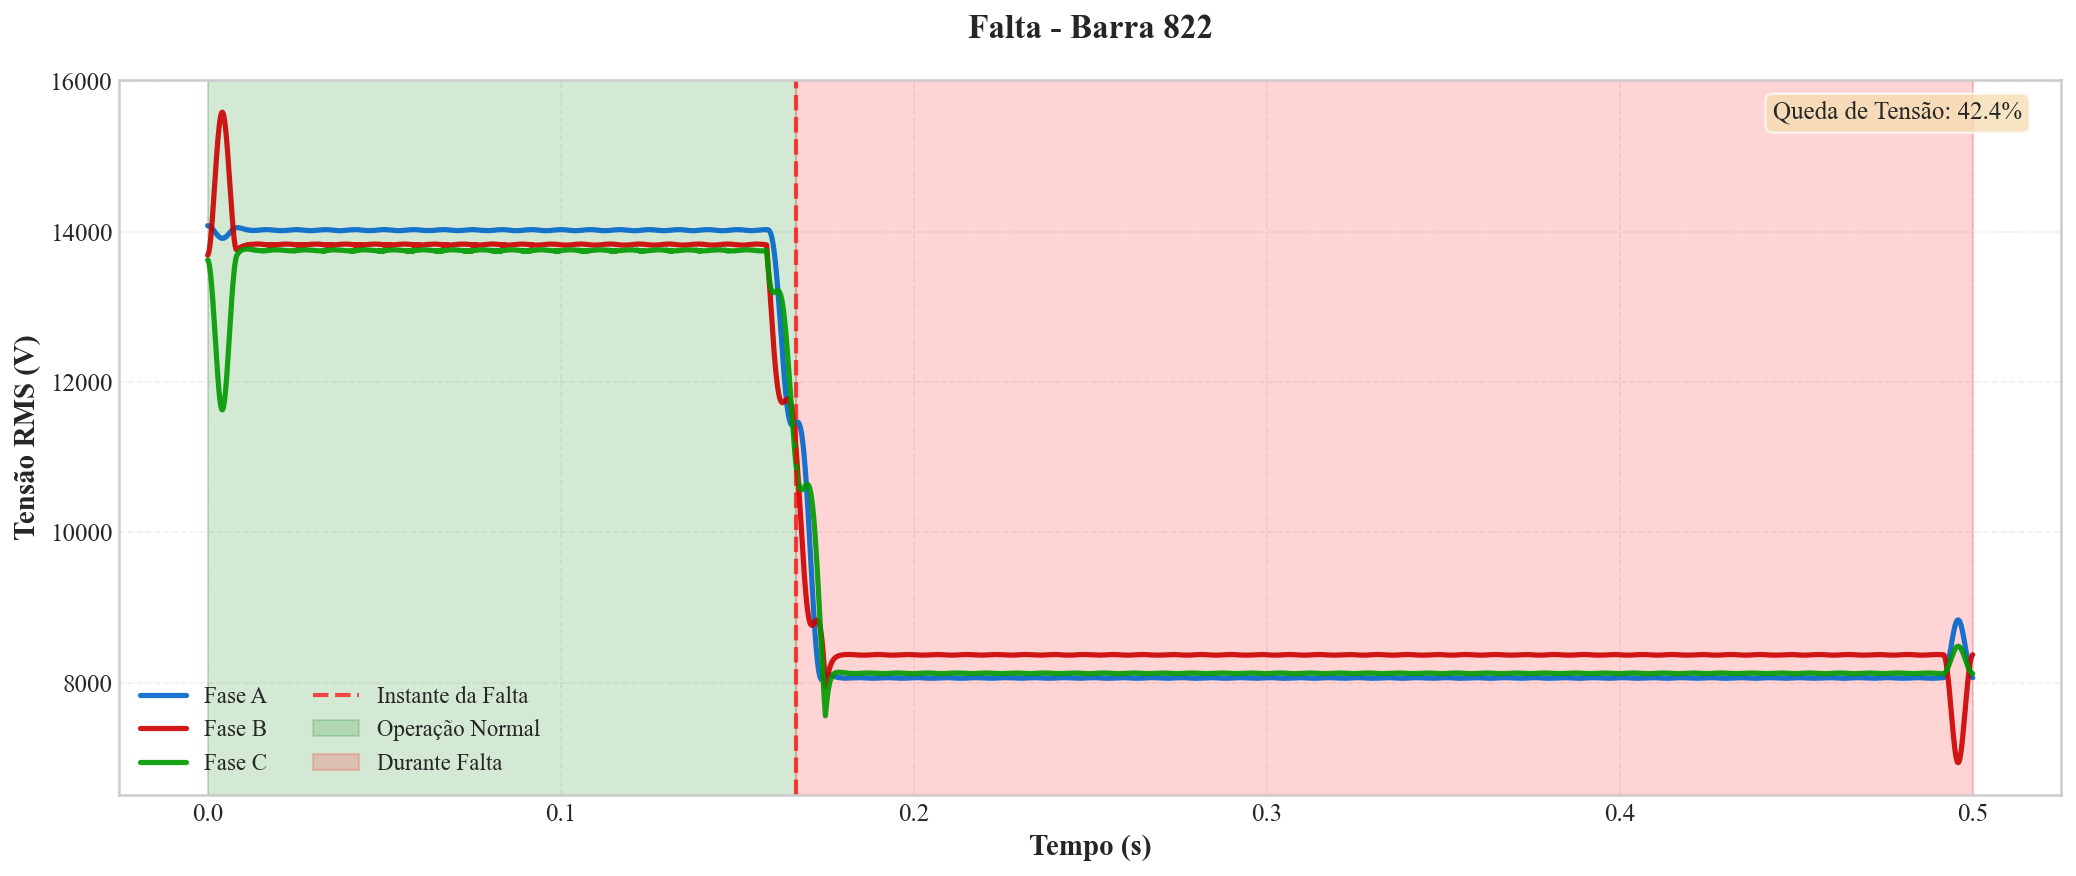

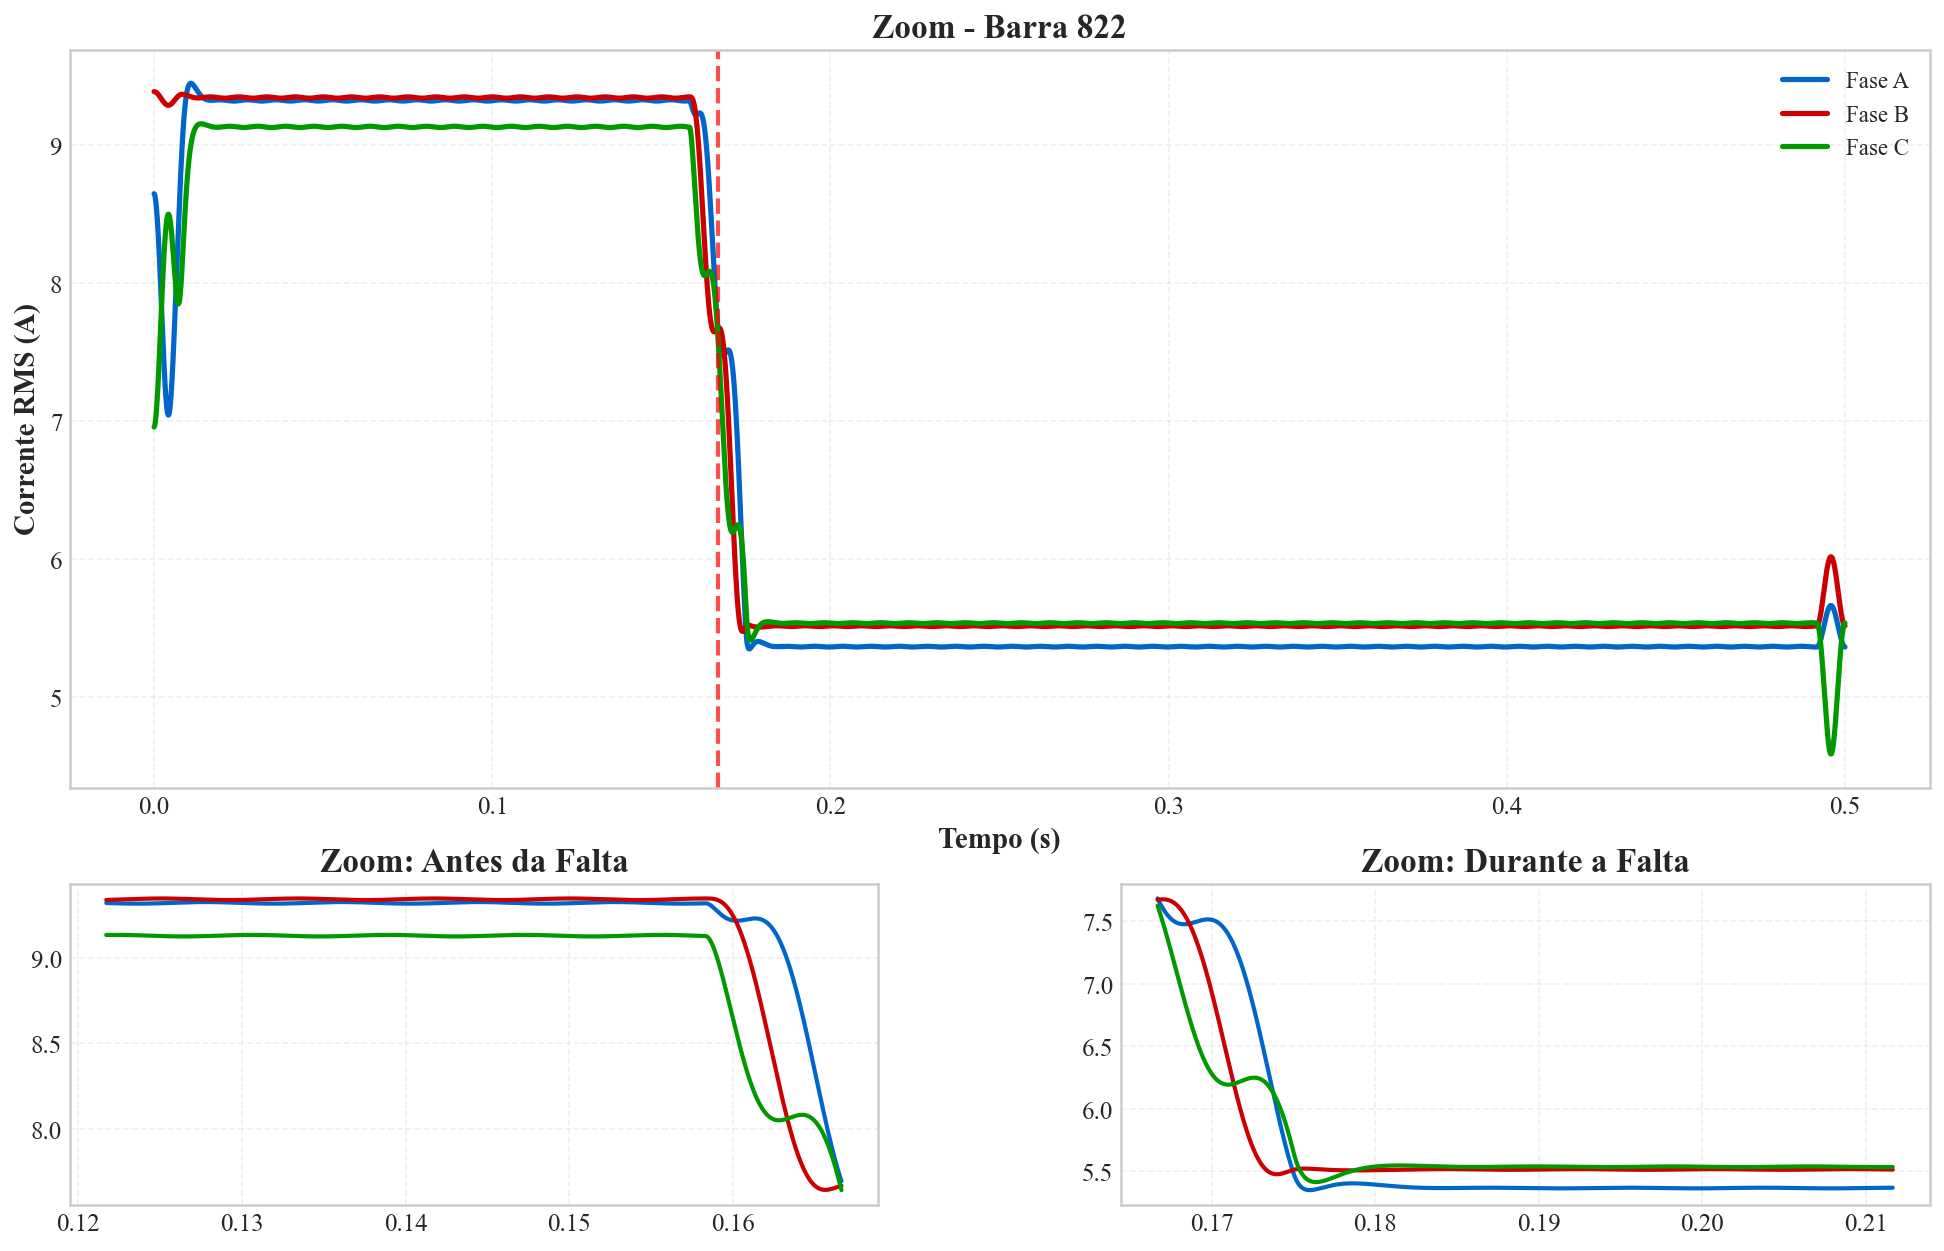

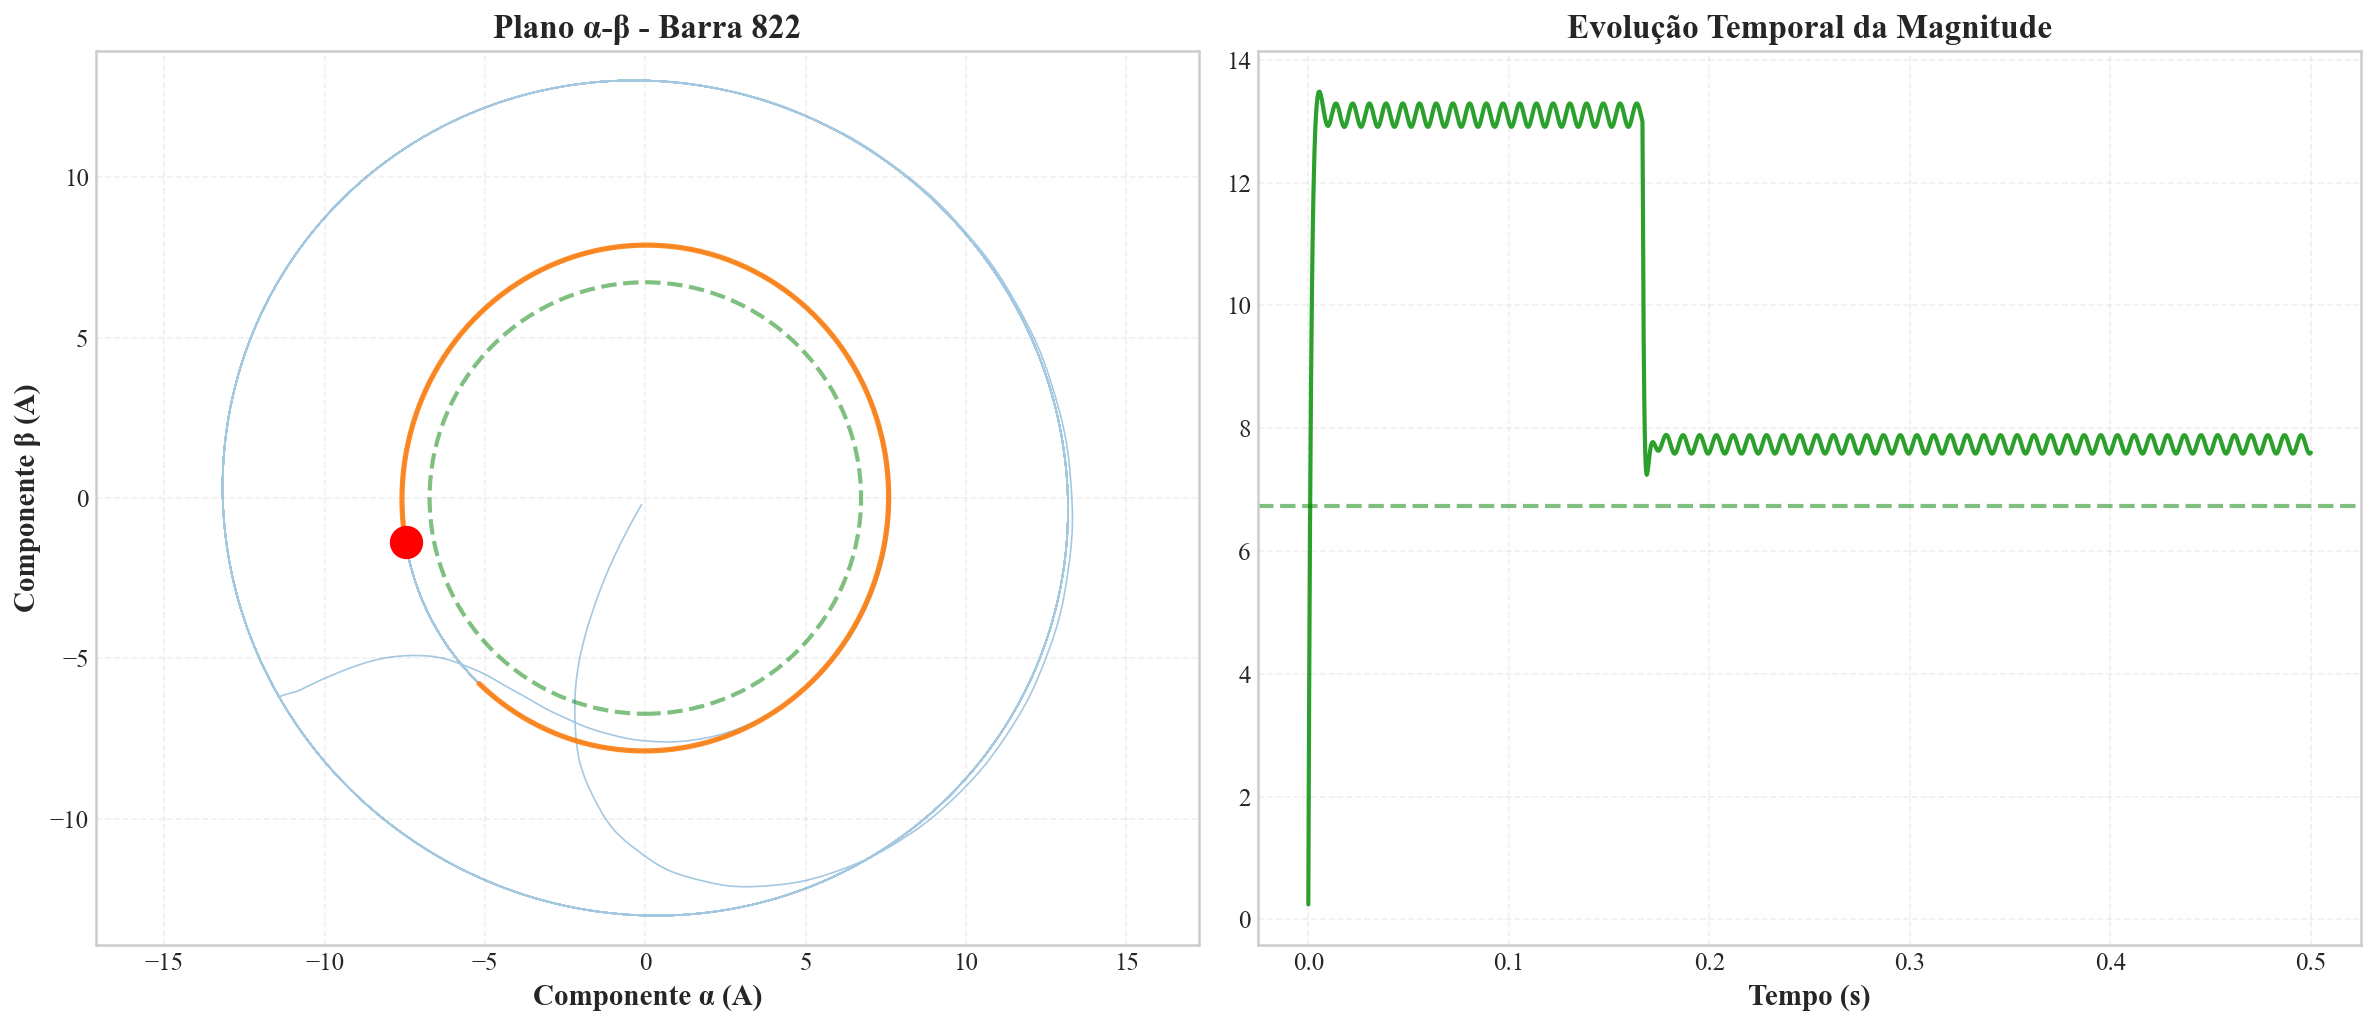

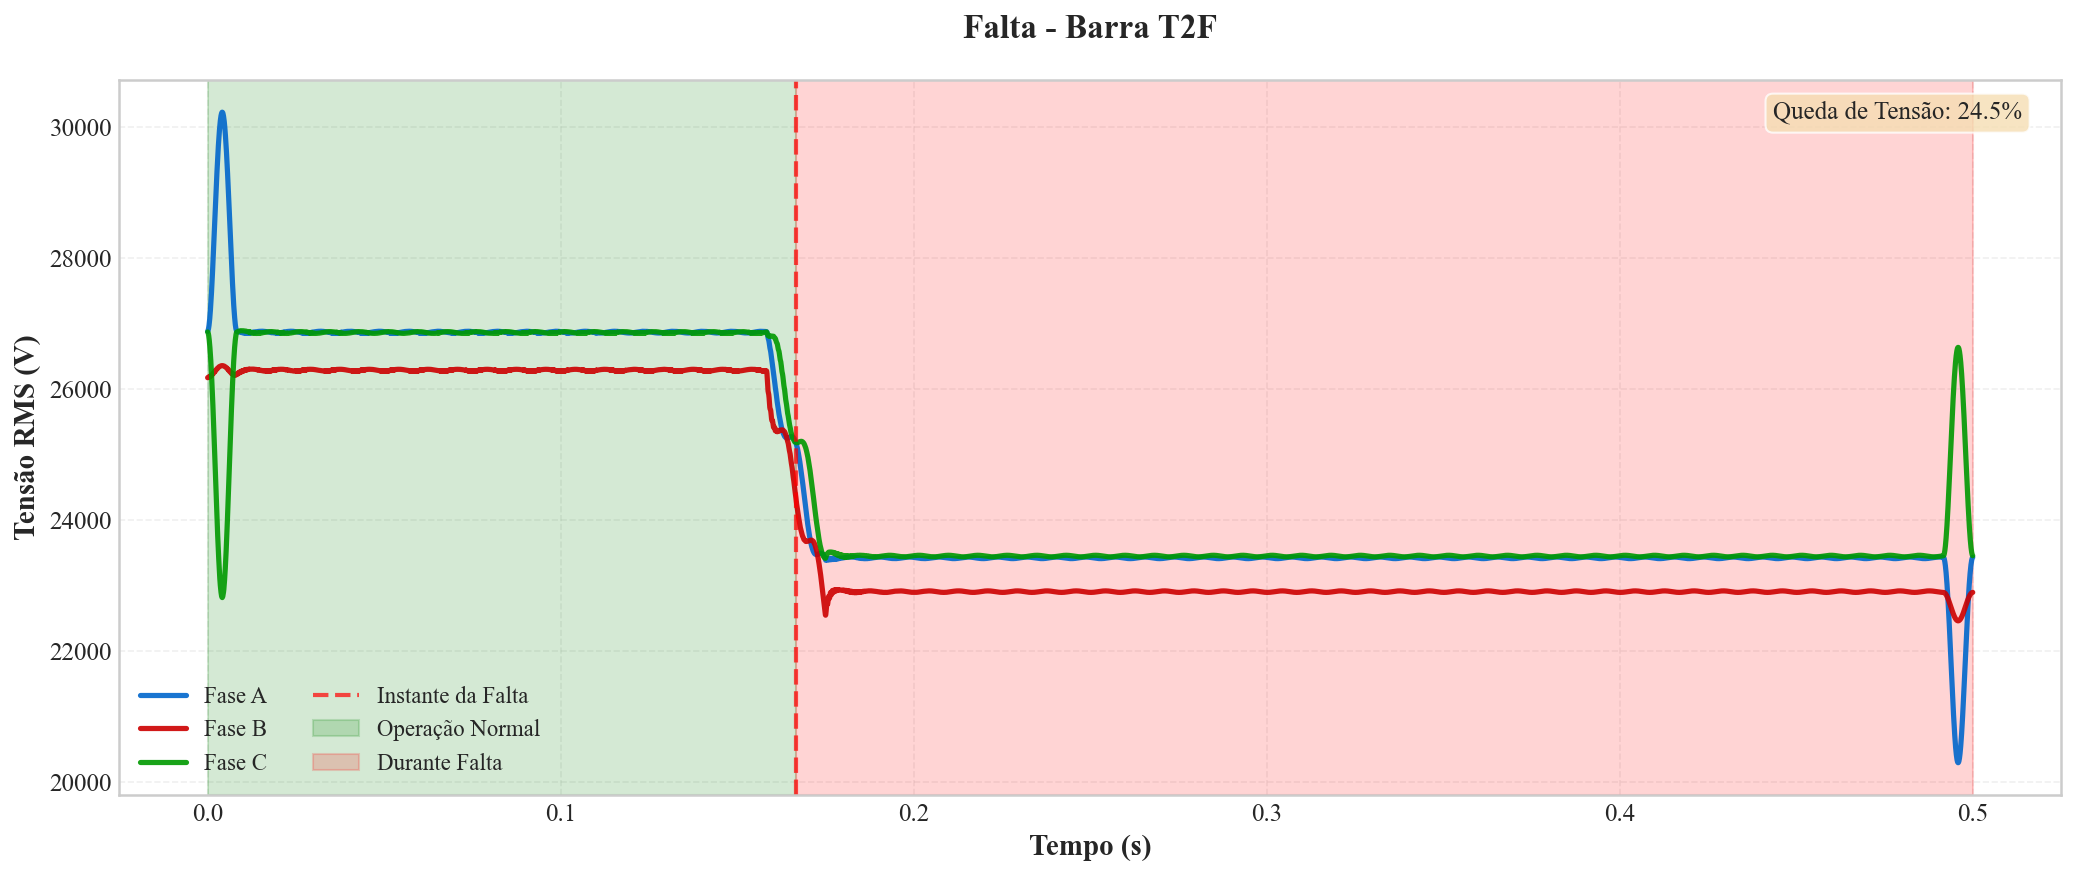

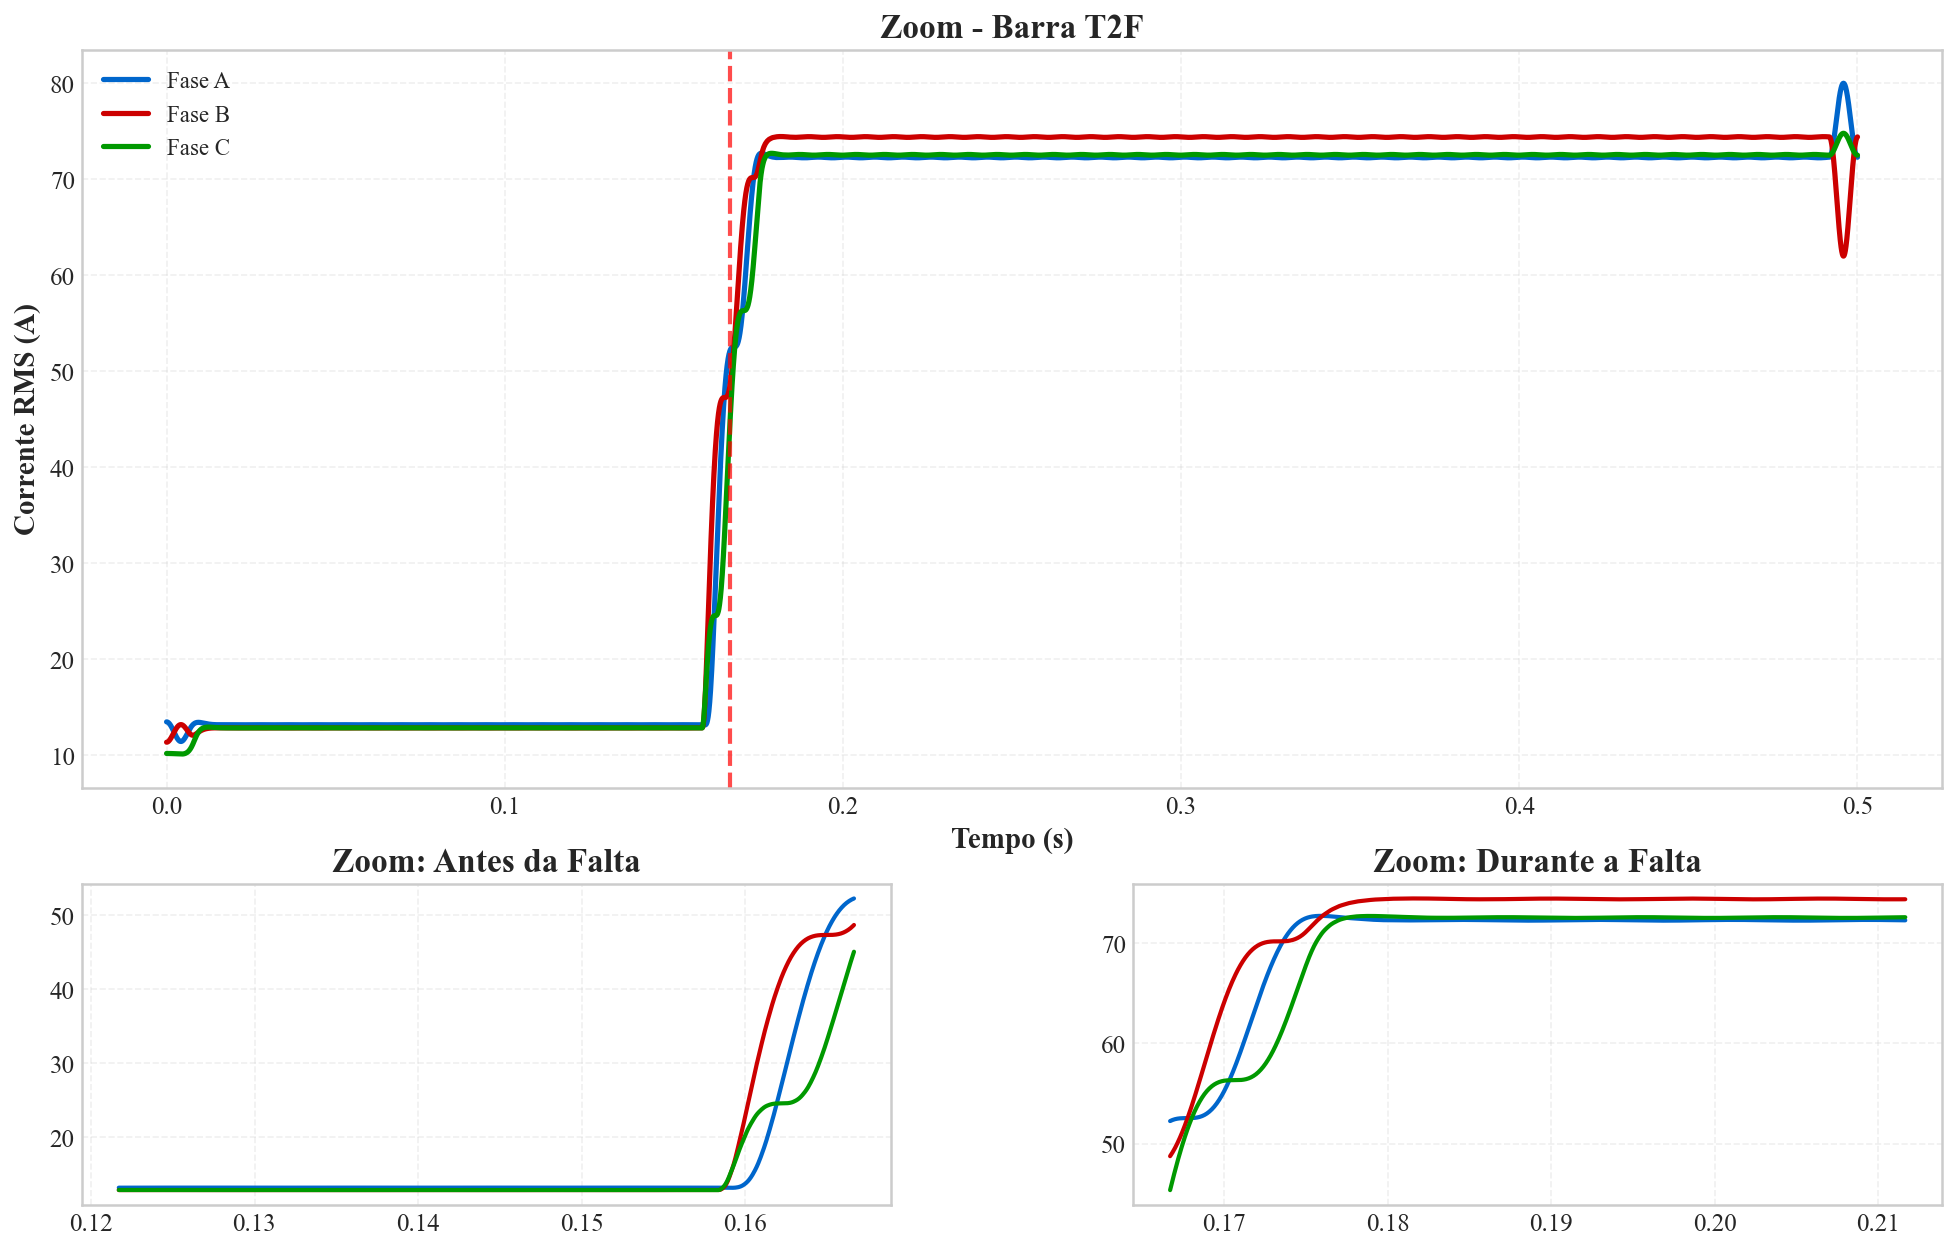

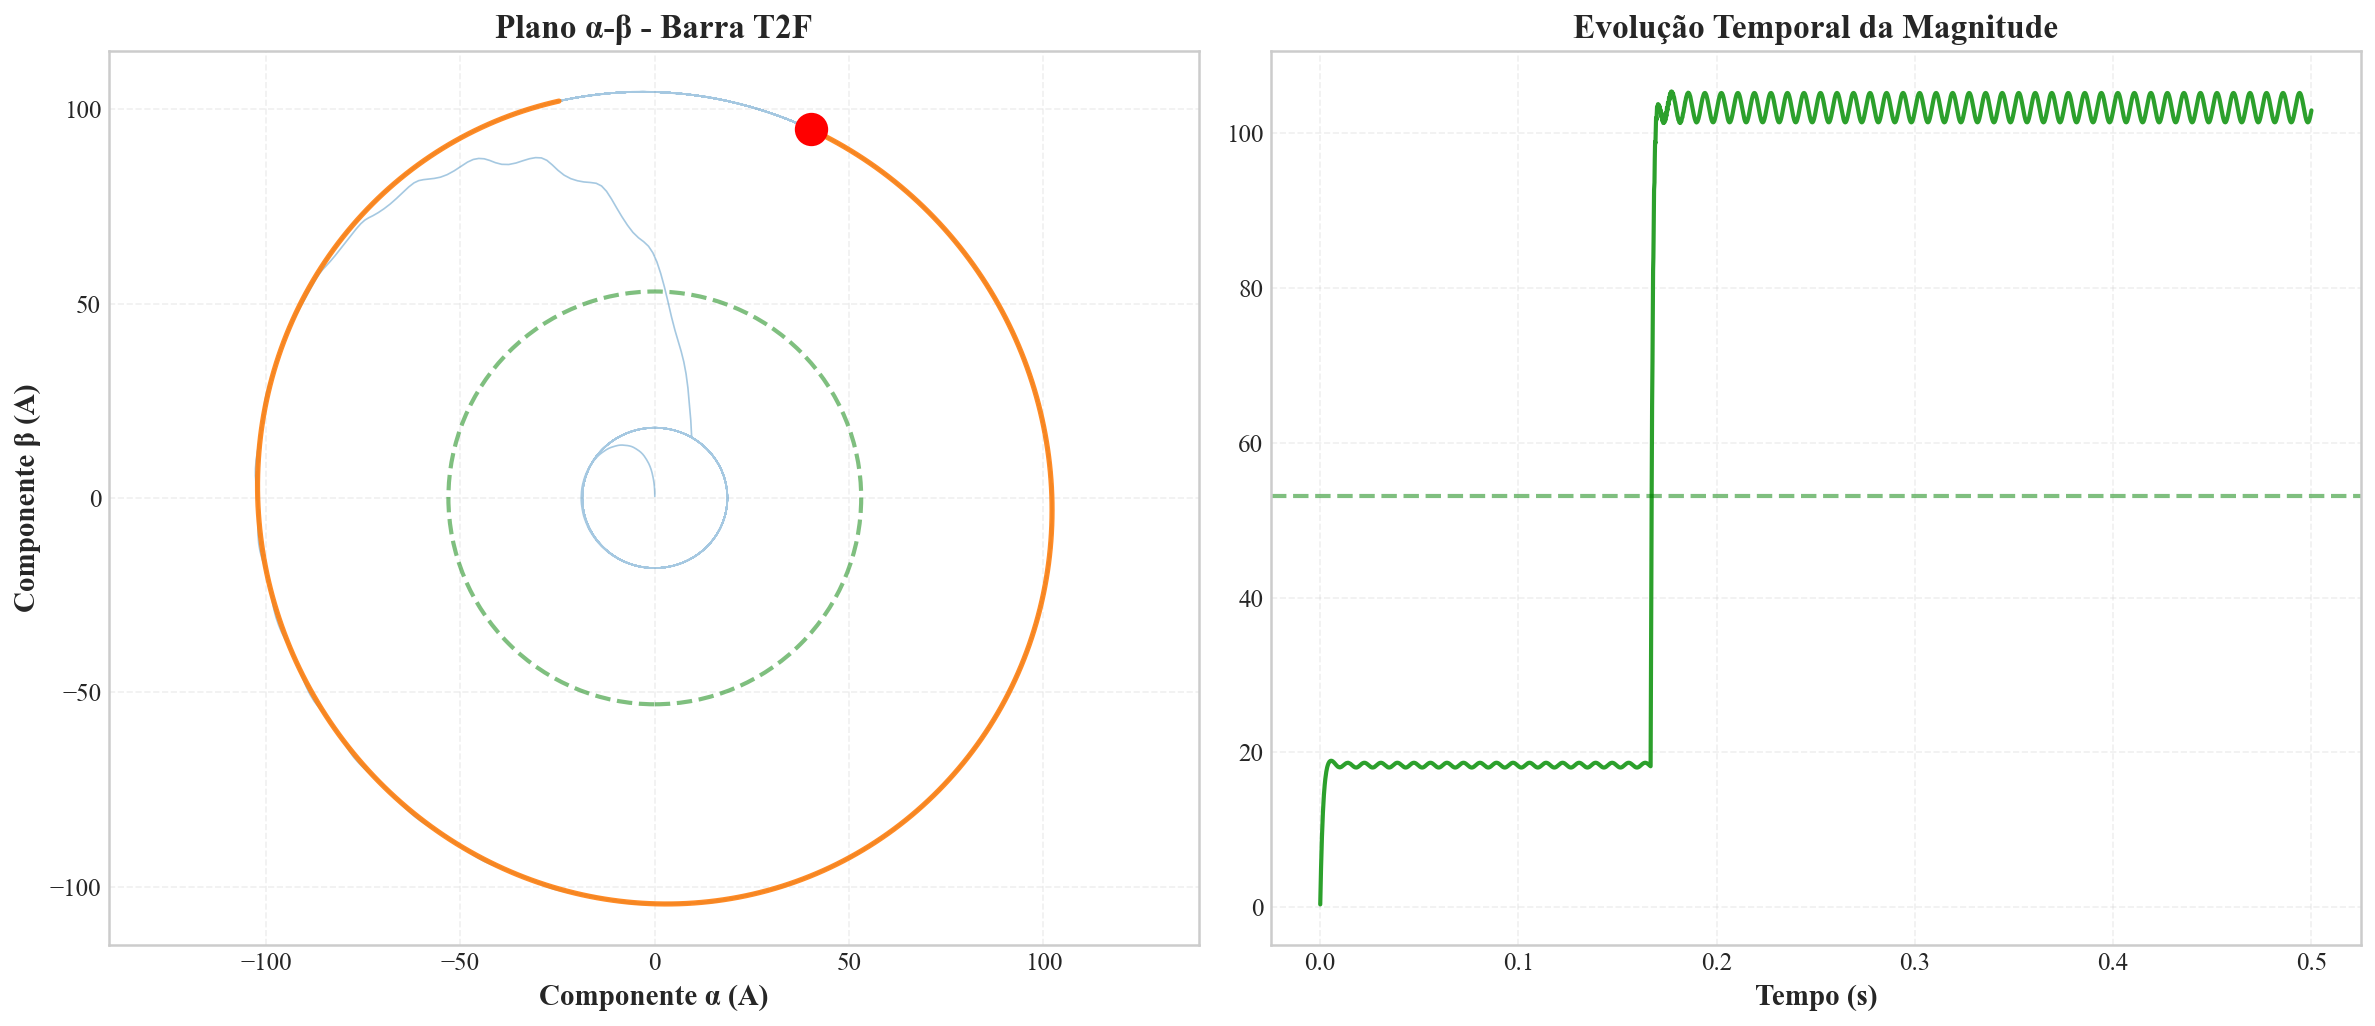

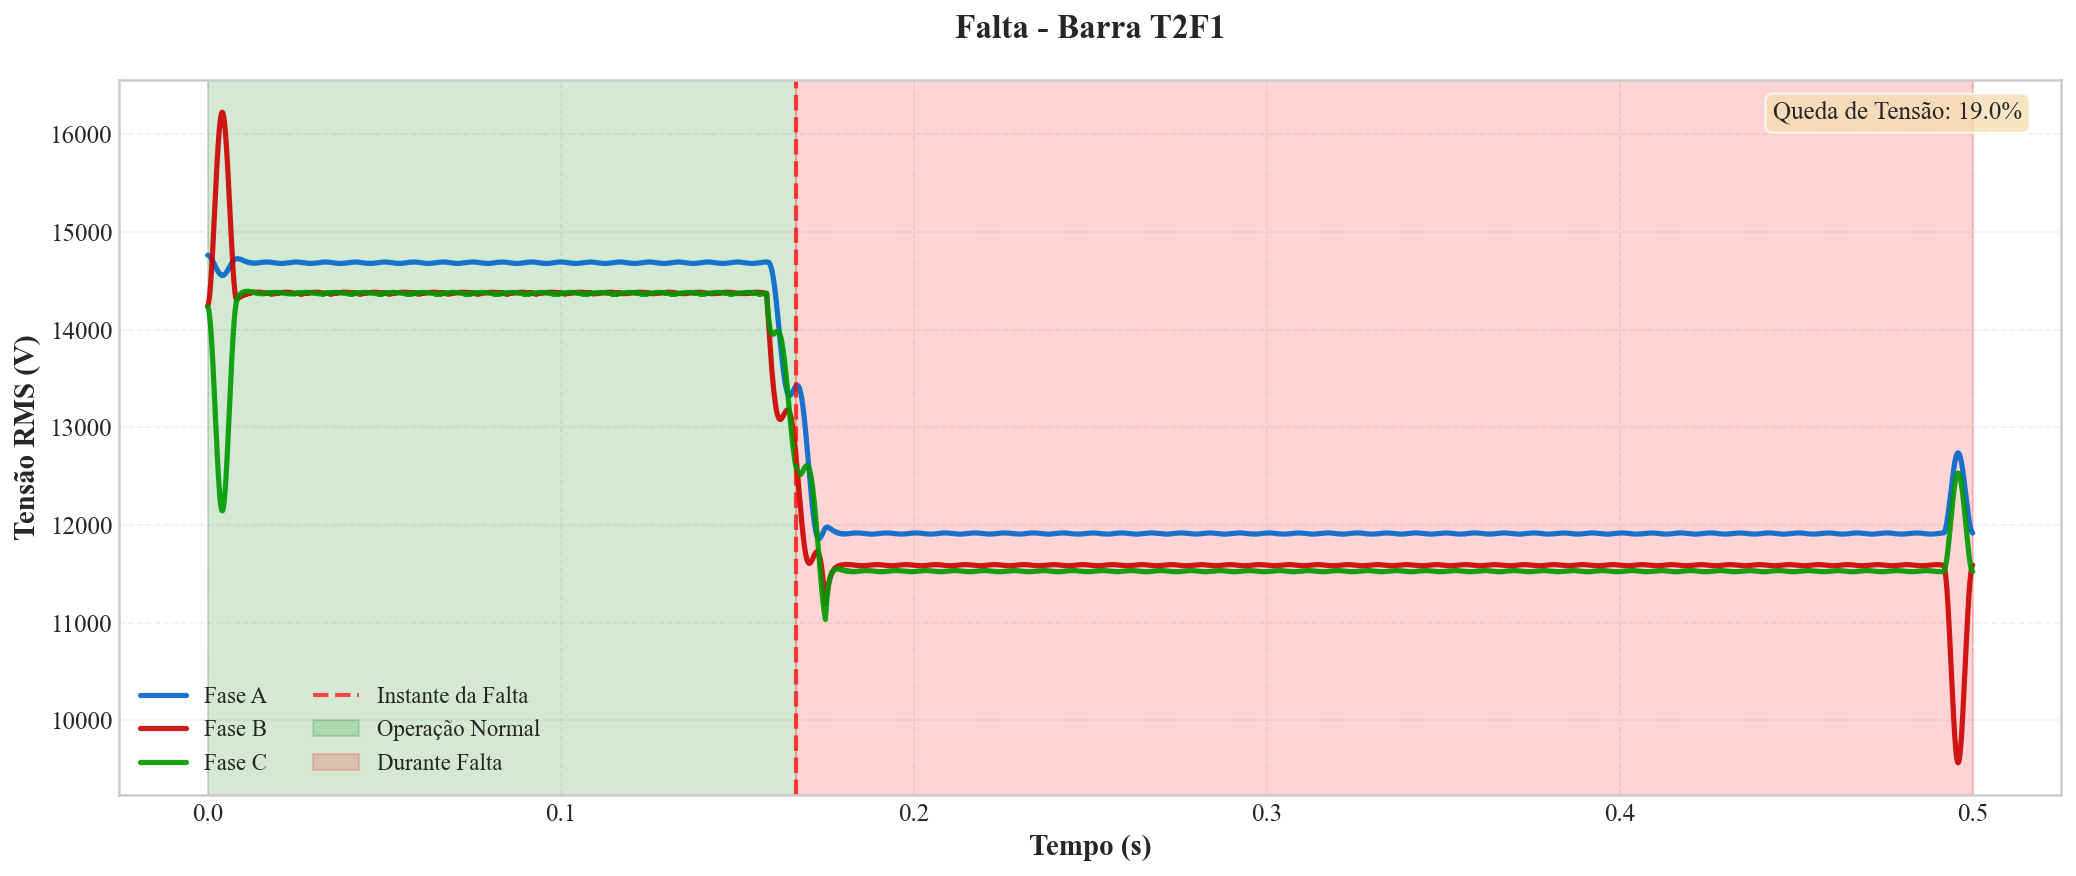

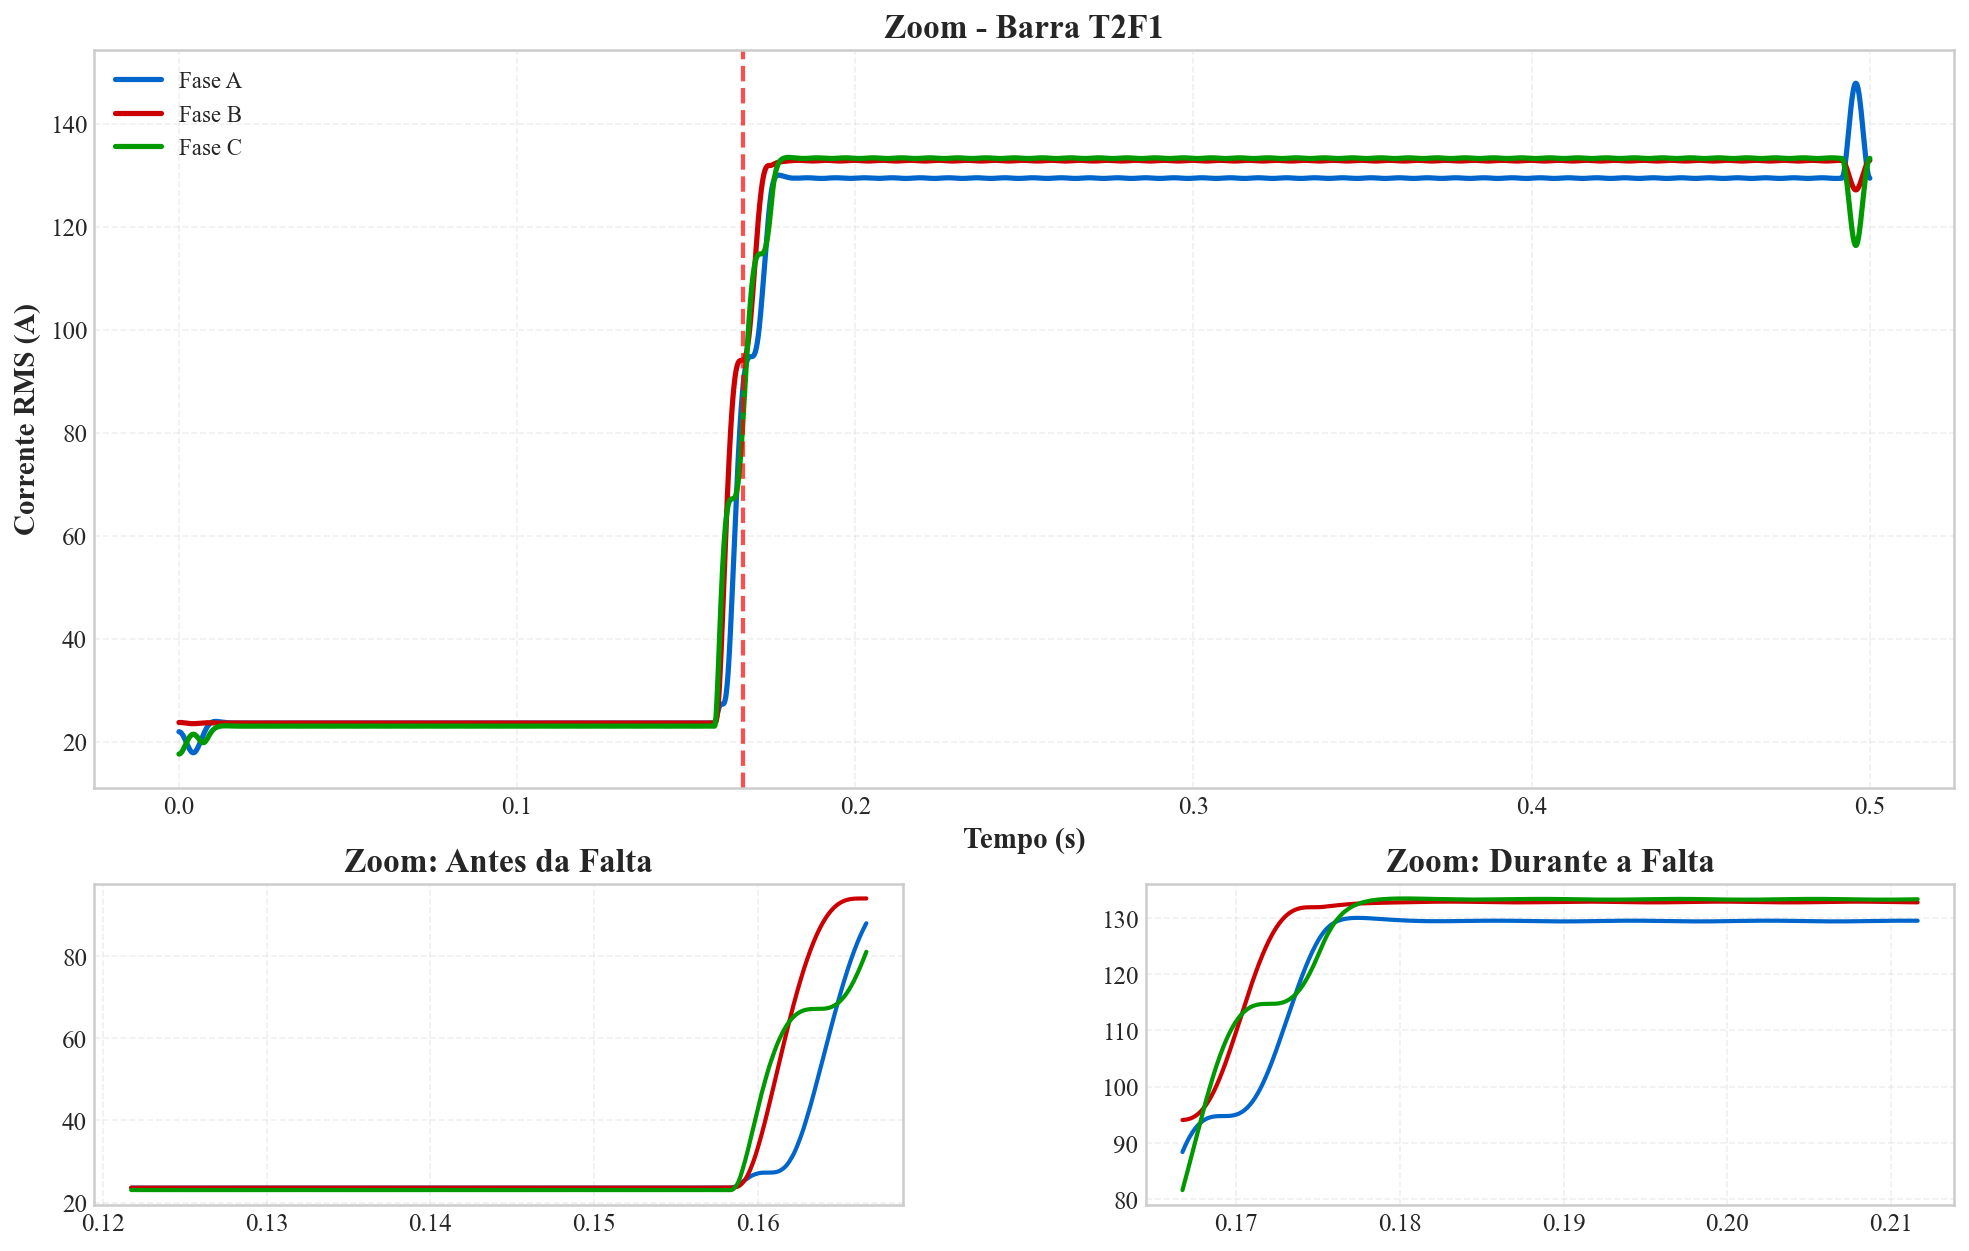

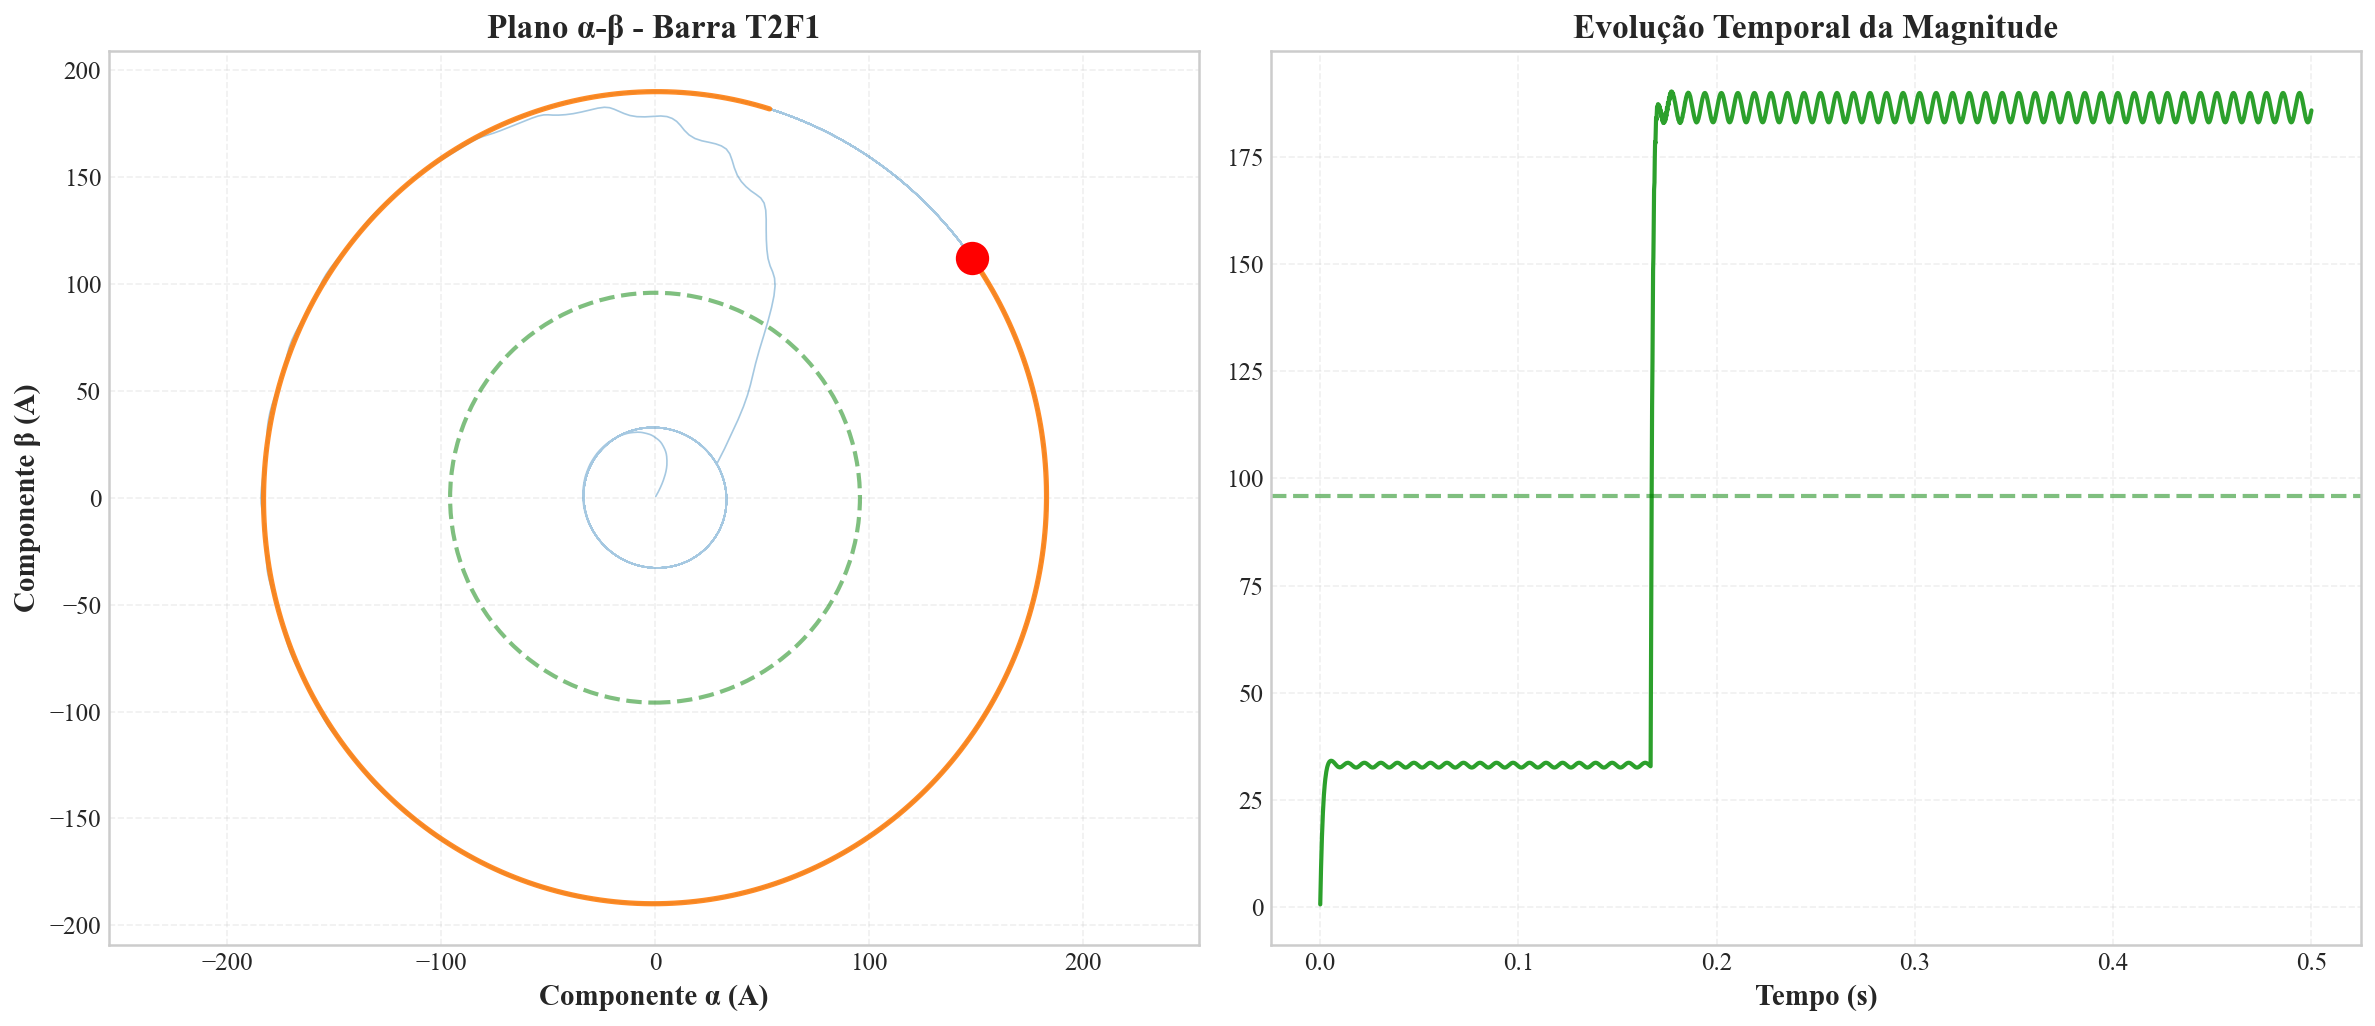

In [8]:
# 🎯 ANÁLISE DE UM ARQUIVO ESPECÍFICO

# Substitua pelo nome real de um arquivo na sua pasta
NOME_ARQUIVO = "Qualificacao__R_820_-_Falta_ABC_py.mat"
ARQUIVO_TESTE = Path(PASTA_DADOS) / NOME_ARQUIVO

if ARQUIVO_TESTE.exists():
    processadores_teste = analisar_arquivo_completo(
        ARQUIVO_TESTE,
        barras_interesse=["800", "818", "820", "822", "T2F", "T2F1"],
        gerar_graficos=True
    )

    if processadores_teste:
        print(f"\n✅ Teste concluído. Barras: {list(processadores_teste.keys())}")

        # Exemplo de exportação avançada para o teste
        pasta_export = PASTA_TESE / "Teste_Exportacao"
        exportar_dados_completos(processadores_teste, pasta_export)
        gerar_relatorio_html(processadores_teste, pasta_export)
else:
    print(f"⚠️ Arquivo não encontrado: {ARQUIVO_TESTE}")

In [ ]:
# 🚀 RODAR ANÁLISE PARA TODOS OS ARQUIVOS DA PASTA_DADOS

resultados_lote = analisar_multiplos_arquivos(
    PASTA_DADOS,
    padrao="*.mat",
    barras_interesse=["800", "818", "820", "822", "T2F", "T2F1"]
)


🚀 ANÁLISE EM LOTE: 328 arquivos encontrados.

🔬 ANALISANDO: MRT_sem_terra__A_818_1_-_Falta_A_py.mat
  ✅ Barra 800: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 818: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 820: 10001 amostras, fs=20000.0 Hz
  ✅ Barra 822: 10001 amostras, fs=20000.0 Hz
  ✅ Barra T2F: 10001 amostras, fs=20000.0 Hz
  ✅ Barra T2F1: 2 amostras, fs=20000.0 Hz

📊 TABELA DE ESTATÍSTICAS
barra  i_max_A  i_max_B  i_max_C  i_media_A  i_media_B  i_media_C   v_max_A  v_max_B   v_max_C
  800    14.94     7.52     7.82       5.35       2.87       3.12 106902.54 100810.1 113162.69
  818    16.67     0.00     0.00       5.92       0.00       0.00 115332.56      0.0      0.00
  820    10.35     0.00     0.00       1.99       0.00       0.00 115283.78      0.0      0.00
  822     5.30     0.00     0.00       1.03       0.00       0.00 115277.24      0.0      0.00
  T2F    16.65     0.00     0.00       5.91       0.00       0.00 115334.39      0.0      0.00
 T2F1     0.00     0.00     0.00    